# Phase 1. Subphase 2. 

Mario Chacón Falcón & Jose M. Moyano.

The goal of this second experiment is to decide which parameter for public_data_prediction works better, common_abs,common_weighted,own,avg_abs,avg_weighted. 

In order to do so, the rest of the model is fixed to its simplest version, which is:

public_data_prediction = ?? both for now

prediction_weights = 'server_and_clients'

balanced_target_client_weights = False

adapt_client_weights = np.ones(Nclients)

Nclients=10

T (iterations) = 10

To test it out, four datasets are selected, adult dataset (unbalanced), nursery dataset (more than 2 labels), bank and breast_cancer.

The test will be done with 6 different seeds, creating each time 5folds, and hence having 30 tests. The mean over the accuracy and f1score of the FL model of all clients is calculated and stored in a dataframe for further statistics tests. 

In [19]:
from flextrees.datasets.tabular_datasets import bank
from flextrees.datasets.tabular_datasets import nursery
from flextrees.datasets.tabular_datasets import adult
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold
from utils.evaluation import FL_simple_cross_val_score
from sklearn.datasets import load_breast_cancer
import time
import math
from statds.no_parametrics import friedman, bonferroni, nemenyi
import os

Let's first load the data

In [20]:
train_data, test_data = bank(ret_feature_names=False, categorical=False)
X_data,y_data = train_data.to_numpy()
X_test,y_test = test_data.to_numpy()
X_data_bank = np.concatenate((X_data,X_test)).astype(int) #Some were bools
targets_bank = np.concatenate((y_data,y_test))
X_data_bank.shape

(45211, 31)

In [21]:
train_data, test_data = adult(ret_feature_names=False, categorical=False)
X_data,y_data = train_data.to_numpy()
X_test,y_test = test_data.to_numpy()
X_data_adult = np.concatenate((X_data,X_test))
targets_adult = np.concatenate((y_data,y_test))
X_data_adult.shape

(32561, 108)

In [22]:
train_data, test_data = nursery(ret_feature_names=False, categorical=False)
X_data,y_data = train_data.to_numpy()
X_test,y_test = test_data.to_numpy()
X_data_nursery = np.concatenate((X_data,X_test))
targets_nursery = np.concatenate((y_data,y_test))
X_data_nursery.shape

(12960, 27)

In [23]:
breast_cancer = load_breast_cancer()
X_data_bcancer = breast_cancer.data
targets_bcancer = breast_cancer.target

In [24]:
#seeds =[0,142,242,342,442,542]
#parameters = ['majority_voting','weighted_majority_voting']
#datasets = {'bank':(X_data_bank,targets_bank),
#            'adult':(X_data_adult,targets_adult),'nursery':(X_data_nursery,targets_nursery)}
#parameterscolumns = ['majority_voting','maj_vot_std','weighted_majority_voting','w_m_v_std']

In [25]:
def experiment2search(datasets,data_distribution,distribution_param = None,public_data_prediction='weighted_majority_voting'):

    #Algorithm parameters:
    Nclients = 10
    #server_alpha_weight_adj = 'own' 
    prediction_weights = 'server_and_clients'
    T = 10
    adapt_client_weight = np.ones(Nclients)
    parameters = ['common_abs','common_weighted','own','avg_abs','avg_weighted']

    #Default settings
    seeds =[0,142,242,342,442,542]
    parameterscolumns = ['common_abs','c_a_std','common_weighted','c_w_std','own','own_std','avg_abs','a_a_std','avg_weighted','a_w_std']

    #Creates dataframes to store avg results : FL on global data, FL on local data, centralized model scores (f1 and acc)
    dataframeacc_globaldata = pd.DataFrame(np.nan, index= datasets.keys(),
                            columns = parameterscolumns)
    dataframeacc_globaldata = dataframeacc_globaldata.rename_axis('FLGlobal_acc',axis=1)
    dataframef1_globaldata = pd.DataFrame(np.nan, index= datasets.keys(),
                            columns = parameterscolumns)
    dataframef1_globaldata = dataframef1_globaldata.rename_axis('FLGlobal_f1',axis=1)
    dataframeacc_localdata = pd.DataFrame(np.nan, index= datasets.keys(),
                            columns = parameterscolumns)
    dataframeacc_localdata = dataframeacc_localdata.rename_axis('FLlocal_acc',axis=1)
    dataframef1_localdata = pd.DataFrame(np.nan, index= datasets.keys(),
                            columns = parameterscolumns)
    dataframef1_localdata = dataframef1_localdata.rename_axis('FLlocal_f1',axis=1)
    dataframe_centralizedacc = pd.DataFrame(np.nan, index = datasets.keys(),columns = ['mean','std'])
    dataframe_centralizedacc = dataframe_centralizedacc.rename_axis('centralized_acc',axis=1)
    dataframe_centralizedf1 = pd.DataFrame(np.nan, index = datasets.keys(),columns = ['mean','std'])
    dataframe_centralizedf1 = dataframe_centralizedf1.rename_axis('centralized_f1',axis=1)

    acc_results = []
    f1_results = []

    #Training of 6 5-folds for each dataset and then gets stored in its corresponding row. 
    for dataset,data in datasets.items():
        data_to_mergeacc = [[]]*len(parameters)
        data_to_mergef1 = [[]]*len(parameters)
        centralized_acc = []
        centralized_f1 = []
        for seed in seeds:
            fulldata,fulltargets = data
            X_data,public_data,y_data,public_data_targets = train_test_split(fulldata,fulltargets,
                                                                            train_size=0.75,random_state=seed)
            #Create folds
            skf = StratifiedKFold(n_splits=5,shuffle=True,random_state=seed)
            indices_iterable = skf.split(X_data,y_data)
            
            dataset_splits = [None]*5
            for i,(filter_train,filter_test) in enumerate(indices_iterable):
                dataset_splits[i] = (X_data[filter_train],X_data[filter_test],
                                    y_data[filter_train],y_data[filter_test])
            
            aux_acc_dataframe = pd.DataFrame(np.nan, index = [dataset+str(seed)]*len(dataset_splits),columns = parameters)
            aux_f1_dataframe = pd.DataFrame(np.nan, index = [dataset+str(seed)]*len(dataset_splits),columns = parameters) 
                
            for i,parameter in enumerate(parameters):
                FLmodels,centralized_models,accDataFrames,F1DataFrames,acc_centralized_model_scores,f1_centralized_model_scores = FL_simple_cross_val_score(dataset_splits,
                                public_data,Nclients=Nclients,
                                public_data_prediction=public_data_prediction,server_alpha_weight_adj=parameter,
                                prediction_weights=prediction_weights,T=T,data_distribution=data_distribution,distribution_param=distribution_param,random_state=seed,
                                adapt_client_weight=adapt_client_weight)
                for j,accDataFrame in enumerate(accDataFrames):
                    aux_acc_dataframe.iloc[j,i] = accDataFrame.loc[:]['FL_acc_global_data'].mean()
                    aux_f1_dataframe.iloc[j,i] = F1DataFrames[j].loc[:]['FL_acc_global_data'].mean()
                
                data_to_mergeacc[i] = data_to_mergeacc[i] + accDataFrames
                data_to_mergef1[i] = data_to_mergef1[i] + F1DataFrames
            
            acc_results.append(aux_acc_dataframe)
            f1_results.append(aux_f1_dataframe)

            #In each parameter the centralized score does not change, hence, we only store the last ones.
            centralized_acc = centralized_acc + acc_centralized_model_scores
            centralized_f1 = centralized_f1 + f1_centralized_model_scores
        #Once we've done all the tests in all the parameters and seeds for the given dataset, we store it in the dataframes and 
        #start with the next one
        for i in range(len(data_to_mergeacc)):
            data_to_mergeacc[i] = pd.concat(data_to_mergeacc[i],axis=0).describe().loc[['mean','std']][['FL_acc_own_data','FL_acc_global_data']]
            data_to_mergef1[i] = pd.concat(data_to_mergef1[i],axis=0).describe().loc[['mean','std']][['FL_acc_own_data','FL_acc_global_data']]
        
        arr_centralized_acc = np.array(centralized_acc)
        arr_centralized_f1 = np.array(centralized_f1)
        dataframeacc = pd.concat(data_to_mergeacc,axis=0)
        dataframef1 = pd.concat(data_to_mergef1,axis=0)
        dataframeacc_globaldata.loc[dataset] = dataframeacc.iloc[:,1].values
        dataframeacc_localdata.loc[dataset] = dataframeacc.iloc[:,0].values
        dataframef1_globaldata.loc[dataset] = dataframef1.iloc[:,1].values
        dataframef1_localdata.loc[dataset] = dataframef1.iloc[:,0].values
        dataframe_centralizedacc.loc[dataset] = (arr_centralized_acc.mean(),arr_centralized_acc.std())
        dataframe_centralizedf1.loc[dataset] = (arr_centralized_f1.mean(),arr_centralized_f1.std())

    statistics_acc = pd.concat(acc_results,axis=0)
    statistics_acc = statistics_acc.rename_axis('FL_global_acc')
    statistics_f1 = pd.concat(f1_results,axis=0)
    statistics_f1 = statistics_f1.rename_axis('FL_global_f1')
    return dataframeacc_globaldata,dataframeacc_localdata,dataframe_centralizedacc,dataframef1_globaldata,dataframef1_localdata,dataframe_centralizedf1,statistics_acc,statistics_f1



In [26]:
datasets = {'bank':(X_data_bank,targets_bank),
            'adult':(X_data_adult,targets_adult),'nursery':(X_data_nursery,targets_nursery),'bcancer':(X_data_bcancer,targets_bcancer)}

# IID Results (weighted)

In [27]:
time0 = time.time()
iidresultsW = experiment2search(data_distribution='iid',datasets=datasets)
print("\n[INFO] Total Time (in minutes) =", (time.time() - time0) / 60)
for result in iidresultsW:
    print(result)

c:\Users\mario\OneDrive\Escritorio\Programs\gitProjects\TFM_EnsembleFL\.venv\Lib\site-packages\sklearn\model_selection\_split.py:737: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(
c:\Users\mario\OneDrive\Escritorio\Programs\gitProjects\TFM_EnsembleFL\.venv\Lib\site-packages\sklearn\model_selection\_split.py:737: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(
c:\Users\mario\OneDrive\Escritorio\Programs\gitProjects\TFM_EnsembleFL\.venv\Lib\site-packages\sklearn\model_selection\_split.py:737: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
c:\Users\mario\OneDrive\Escritorio\Programs\gitProjects\TFM_EnsembleFL\.venv\Lib\site-packages\sklearn\model_selection\_split.py:737: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
c:\Users\mario\O


[INFO] Total Time (in minutes) = 24.280717364947
FLGlobal_acc  common_abs   c_a_std  common_weighted   c_w_std        own  \
bank           85.010670  0.587265        85.010670  0.587265  85.010670   
adult          80.248294  0.783068        80.248294  0.783068  80.248294   
nursery        90.741255  1.163418        90.741255  1.163418  90.791495   
bcancer        89.000046  4.270918        89.000046  4.270918  89.136890   

FLGlobal_acc   own_std    avg_abs   a_a_std  avg_weighted   a_w_std  
bank          0.587265  85.010670  0.587265     85.010670  0.587265  
adult         0.783068  80.248294  0.783068     80.248294  0.783068  
nursery       1.167977  90.764403  1.167122     90.764403  1.167122  
bcancer       4.099958  89.062882  4.268338     89.062882  4.268338  
FLlocal_acc  common_abs    c_a_std  common_weighted    c_w_std        own  \
bank          84.944853   2.082577        84.944853   2.082577  84.944853   
adult         80.221088   2.962022        80.221088   2.962022  8

# Accuracy statistical test

In [28]:
_,_,_,_,_,_,acc_results,f1_results = iidresultsW
acc_results2 = acc_results.round(decimals=3).reset_index()
path = os.path.abspath('') + '\\exp2results\\w_iidacc'
acc_results2.to_csv(path_or_buf=path)
alpha = 0.05
rankings, statistic, p_value, critical_value, hypothesis = friedman(acc_results2, alpha, minimize=False)
print("Accuracy results:\n")
print(hypothesis)
print(f"Statistic {statistic}, p-value {p_value}")
print(rankings)

Accuracy results:

Reject H0 with alpha = 0.05 (Different distributions)
Statistic 27.558333333333394, p-value 1.532620186395217e-05
{'common_abs': 3.370833333333333, 'common_weighted': 3.370833333333333, 'own': 2.475, 'avg_abs': 2.8916666666666666, 'avg_weighted': 2.8916666666666666}


[3.370833333333333, 3.370833333333333, 2.475, 2.8916666666666666, 2.8916666666666666]
0.5568046824928988


C:\Users\mario\AppData\Local\Temp\ipykernel_26668\3434521576.py:5: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  figure.show()


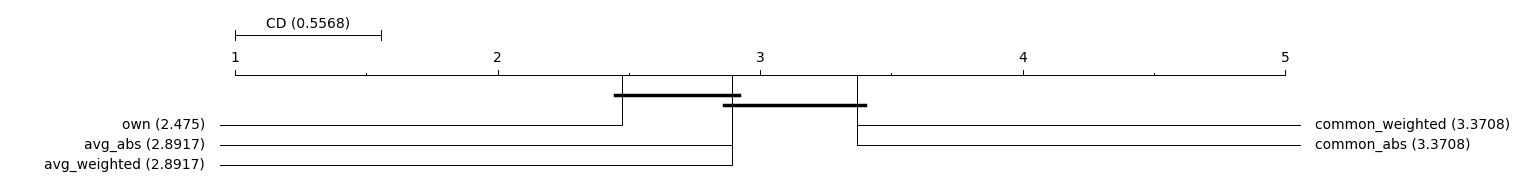

In [29]:

num_cases = acc_results2.shape[0]
ranks_values, critical_distance_nemenyi, figure = nemenyi(rankings, num_cases, alpha)
print(ranks_values)
print(critical_distance_nemenyi)
figure.show()


                        Comparison  Statistic (Z)   p-value  Adjusted alpha  \
0    common_abs vs common_weighted       0.000000  1.000000           0.005   
1                common_abs vs own       4.388669  0.000011           0.005   
2            common_abs vs avg_abs       2.347428  0.018904           0.005   
3       common_abs vs avg_weighted       2.347428  0.018904           0.005   
4           common_weighted vs own       4.388669  0.000011           0.005   
5       common_weighted vs avg_abs       2.347428  0.018904           0.005   
6  common_weighted vs avg_weighted       2.347428  0.018904           0.005   
7                   own vs avg_abs       2.041241  0.041227           0.005   
8              own vs avg_weighted       2.041241  0.041227           0.005   
9          avg_abs vs avg_weighted       0.000000  1.000000           0.005   

   Adjusted p-value  alpha            Results  
0          1.000000   0.05  Fail to Reject H0  
1          0.000114   0.05        

C:\Users\mario\AppData\Local\Temp\ipykernel_26668\844582222.py:3: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  figure.show()


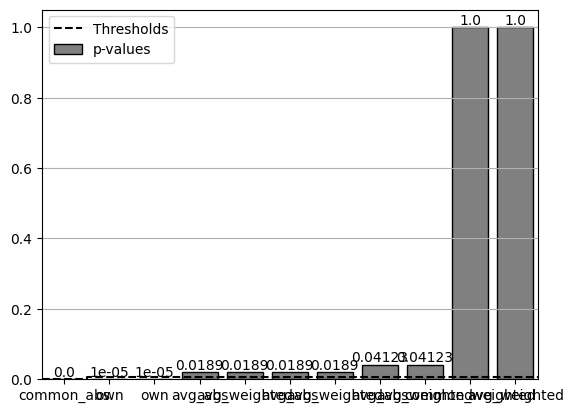

In [30]:

results, figure = bonferroni(rankings, num_cases, alpha, control = None, type_rank = "Friedman")
print(results)
figure.show()


# F1 score statistical test


In [31]:

f1_results2 = f1_results.round(decimals=3).reset_index()
path = os.path.abspath('') + '\\exp2results\\w_iidf1'
f1_results2.to_csv(path_or_buf=path)

alpha = 0.05
rankings, statistic, p_value, critical_value, hypothesis = friedman(f1_results2, alpha, minimize=False)
print("F1-score results:\n")
print(hypothesis)
print(f"Statistic {statistic}, p-value {p_value}")
print(rankings)


F1-score results:

Reject H0 with alpha = 0.05 (Different distributions)
Statistic 32.48000000000002, p-value 1.5261864617643894e-06
{'common_abs': 3.4166666666666665, 'common_weighted': 3.4166666666666665, 'own': 2.466666666666667, 'avg_abs': 2.85, 'avg_weighted': 2.85}


[3.4166666666666665, 3.4166666666666665, 2.466666666666667, 2.85, 2.85]
0.5568046824928988


C:\Users\mario\AppData\Local\Temp\ipykernel_26668\2903514658.py:5: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  figure.show()


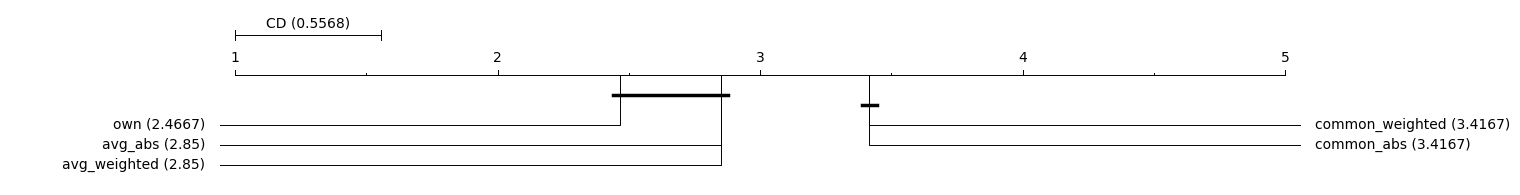

In [32]:

num_cases = f1_results2.shape[0]
ranks_values, critical_distance_nemenyi, figure = nemenyi(rankings, num_cases, alpha)
print(ranks_values)
print(critical_distance_nemenyi)
figure.show()


                        Comparison  Statistic (Z)   p-value  Adjusted alpha  \
0    common_abs vs common_weighted       0.000000  1.000000           0.005   
1                common_abs vs own       4.654031  0.000003           0.005   
2            common_abs vs avg_abs       2.776088  0.005502           0.005   
3       common_abs vs avg_weighted       2.776088  0.005502           0.005   
4           common_weighted vs own       4.654031  0.000003           0.005   
5       common_weighted vs avg_abs       2.776088  0.005502           0.005   
6  common_weighted vs avg_weighted       2.776088  0.005502           0.005   
7                   own vs avg_abs       1.877942  0.060389           0.005   
8              own vs avg_weighted       1.877942  0.060389           0.005   
9          avg_abs vs avg_weighted       0.000000  1.000000           0.005   

   Adjusted p-value  alpha            Results  
0          1.000000   0.05  Fail to Reject H0  
1          0.000033   0.05        

C:\Users\mario\AppData\Local\Temp\ipykernel_26668\2445730000.py:3: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  figure.show()


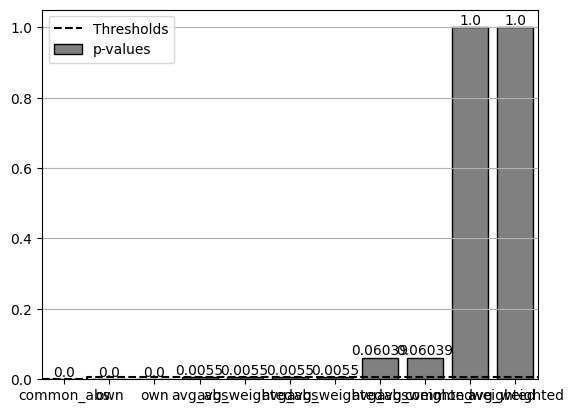

In [33]:

results, figure = bonferroni(rankings, num_cases, alpha, control = None, type_rank = "Friedman")
print(results)
figure.show()

# IID results (m_v)

In [34]:
time0 = time.time()
iidresults = experiment2search(data_distribution='iid',datasets=datasets,public_data_prediction='majority_voting')
print("\n[INFO] Total Time (in minutes) =", (time.time() - time0) / 60)
for result in iidresults:
    print(result)

c:\Users\mario\OneDrive\Escritorio\Programs\gitProjects\TFM_EnsembleFL\.venv\Lib\site-packages\sklearn\model_selection\_split.py:737: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(
c:\Users\mario\OneDrive\Escritorio\Programs\gitProjects\TFM_EnsembleFL\.venv\Lib\site-packages\sklearn\model_selection\_split.py:737: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(
c:\Users\mario\OneDrive\Escritorio\Programs\gitProjects\TFM_EnsembleFL\.venv\Lib\site-packages\sklearn\model_selection\_split.py:737: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
c:\Users\mario\OneDrive\Escritorio\Programs\gitProjects\TFM_EnsembleFL\.venv\Lib\site-packages\sklearn\model_selection\_split.py:737: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
c:\Users\mario\O


[INFO] Total Time (in minutes) = 16.938447292645773
FLGlobal_acc  common_abs   c_a_std  common_weighted   c_w_std        own  \
bank           85.010670  0.587265        85.010670  0.587265  85.010670   
adult          80.248294  0.783068        80.248294  0.783068  80.248294   
nursery        90.647119  1.172787        90.647119  1.172787  90.647119   
bcancer        88.436389  4.357873        88.436389  4.357873  88.436389   

FLGlobal_acc   own_std    avg_abs   a_a_std  avg_weighted   a_w_std  
bank          0.587265  85.010670  0.587265     85.010670  0.587265  
adult         0.783068  80.248294  0.783068     80.248294  0.783068  
nursery       1.172787  90.647119  1.172787     90.647119  1.172787  
bcancer       4.357873  88.436389  4.357873     88.436389  4.357873  
FLlocal_acc  common_abs    c_a_std  common_weighted    c_w_std        own  \
bank          84.944853   2.082577        84.944853   2.082577  84.944853   
adult         80.221088   2.962022        80.221088   2.962022

# Accuracy results

In [35]:
_,_,_,_,_,_,acc_results,f1_results = iidresults
acc_results2 = acc_results.round(decimals=3).reset_index()
path = os.path.abspath('') + '\\exp2results\\iidacc'
acc_results2.to_csv(path_or_buf=path)

alpha = 0.05

rankings, statistic, p_value, critical_value, hypothesis = friedman(acc_results2, alpha, minimize=False)
print("Accuracy results:\n")
print(hypothesis)
print(f"Statistic {statistic}, p-value {p_value}")
print(rankings)


Accuracy results:

Fail to Reject H0 with alpha = 0.05 (Same distributions)
Statistic 0.0, p-value 1.0
{'common_abs': 3.0, 'common_weighted': 3.0, 'own': 3.0, 'avg_abs': 3.0, 'avg_weighted': 3.0}


[3.0, 3.0, 3.0, 3.0, 3.0]
0.5568046824928988


C:\Users\mario\AppData\Local\Temp\ipykernel_26668\3434521576.py:5: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  figure.show()


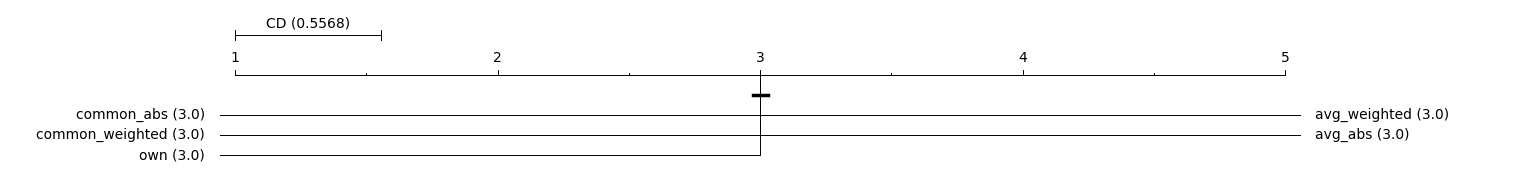

In [36]:

num_cases = acc_results2.shape[0]
ranks_values, critical_distance_nemenyi, figure = nemenyi(rankings, num_cases, alpha)
print(ranks_values)
print(critical_distance_nemenyi)
figure.show()


                        Comparison  Statistic (Z)  p-value  Adjusted alpha  \
0    common_abs vs common_weighted            0.0      1.0           0.005   
1                common_abs vs own            0.0      1.0           0.005   
2            common_abs vs avg_abs            0.0      1.0           0.005   
3       common_abs vs avg_weighted            0.0      1.0           0.005   
4           common_weighted vs own            0.0      1.0           0.005   
5       common_weighted vs avg_abs            0.0      1.0           0.005   
6  common_weighted vs avg_weighted            0.0      1.0           0.005   
7                   own vs avg_abs            0.0      1.0           0.005   
8              own vs avg_weighted            0.0      1.0           0.005   
9          avg_abs vs avg_weighted            0.0      1.0           0.005   

   Adjusted p-value  alpha            Results  
0                 1   0.05  Fail to Reject H0  
1                 1   0.05  Fail to Reject H0

C:\Users\mario\AppData\Local\Temp\ipykernel_26668\844582222.py:3: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  figure.show()


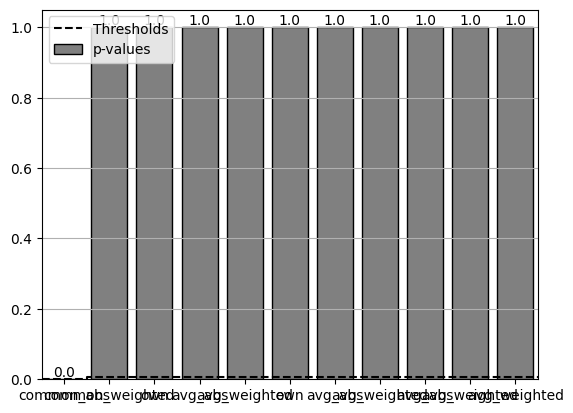

In [37]:

results, figure = bonferroni(rankings, num_cases, alpha, control = None, type_rank = "Friedman")
print(results)
figure.show()


# F1 score statistical test


In [38]:

f1_results2 = f1_results.round(decimals=3).reset_index()
alpha = 0.05
path = os.path.abspath('') + '\\exp2results\\iidf1'
f1_results2.to_csv(path_or_buf=path)

rankings, statistic, p_value, critical_value, hypothesis = friedman(f1_results2, alpha, minimize=False)
print("F1-score results:\n")
print(hypothesis)
print(f"Statistic {statistic}, p-value {p_value}")
print(rankings)


F1-score results:

Fail to Reject H0 with alpha = 0.05 (Same distributions)
Statistic 0.0, p-value 1.0
{'common_abs': 3.0, 'common_weighted': 3.0, 'own': 3.0, 'avg_abs': 3.0, 'avg_weighted': 3.0}


[3.0, 3.0, 3.0, 3.0, 3.0]
0.5568046824928988


C:\Users\mario\AppData\Local\Temp\ipykernel_26668\2903514658.py:5: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  figure.show()


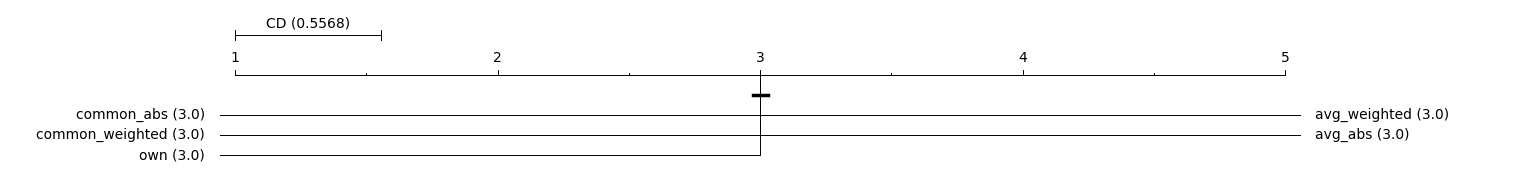

In [39]:

num_cases = f1_results2.shape[0]
ranks_values, critical_distance_nemenyi, figure = nemenyi(rankings, num_cases, alpha)
print(ranks_values)
print(critical_distance_nemenyi)
figure.show()


                        Comparison  Statistic (Z)  p-value  Adjusted alpha  \
0    common_abs vs common_weighted            0.0      1.0           0.005   
1                common_abs vs own            0.0      1.0           0.005   
2            common_abs vs avg_abs            0.0      1.0           0.005   
3       common_abs vs avg_weighted            0.0      1.0           0.005   
4           common_weighted vs own            0.0      1.0           0.005   
5       common_weighted vs avg_abs            0.0      1.0           0.005   
6  common_weighted vs avg_weighted            0.0      1.0           0.005   
7                   own vs avg_abs            0.0      1.0           0.005   
8              own vs avg_weighted            0.0      1.0           0.005   
9          avg_abs vs avg_weighted            0.0      1.0           0.005   

   Adjusted p-value  alpha            Results  
0                 1   0.05  Fail to Reject H0  
1                 1   0.05  Fail to Reject H0

C:\Users\mario\AppData\Local\Temp\ipykernel_26668\2445730000.py:3: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  figure.show()


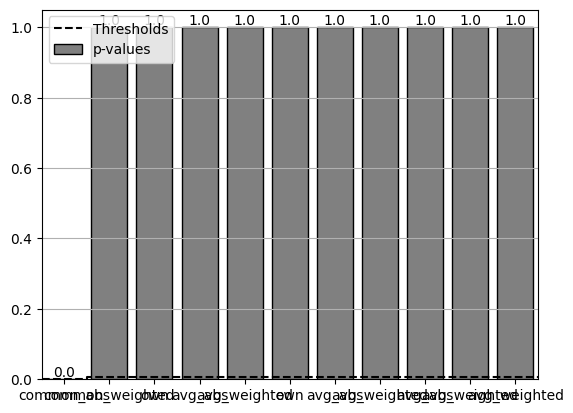

In [40]:

results, figure = bonferroni(rankings, num_cases, alpha, control = None, type_rank = "Friedman")
print(results)
figure.show()

# overall Comparison


In [41]:

# Accuracy
_,_,_,_,_,_,acc_resultsW,f1_resultsW = iidresultsW
acc_resultsW.columns =acc_resultsW.columns + '_W_m_v'
fullacc_results = pd.concat([acc_resultsW,acc_results],axis=1).reset_index()
alpha = 0.05
rankings, statistic, p_value, critical_value, hypothesis = friedman(fullacc_results, alpha, minimize=False)
print("Overall comparison:\n")
print(hypothesis)
print(f"Statistic {statistic}, p-value {p_value}")
print(rankings)



Overall comparison:

Reject H0 with alpha = 0.05 (Different distributions)
Statistic 157.13409090909136, p-value 1.1090817153558419e-10
{'common_abs_W_m_v': 4.891666666666667, 'common_weighted_W_m_v': 4.891666666666667, 'own_W_m_v': 3.85, 'avg_abs_W_m_v': 4.2875, 'avg_weighted_W_m_v': 4.2875, 'common_abs': 6.558333333333334, 'common_weighted': 6.558333333333334, 'own': 6.558333333333334, 'avg_abs': 6.558333333333334, 'avg_weighted': 6.558333333333334}


[4.891666666666667, 4.891666666666667, 3.85, 4.2875, 4.2875, 6.558333333333334, 6.558333333333334, 6.558333333333334, 6.558333333333334, 6.558333333333334]
1.2365825476883405


C:\Users\mario\AppData\Local\Temp\ipykernel_26668\3658350887.py:5: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  figure.show()


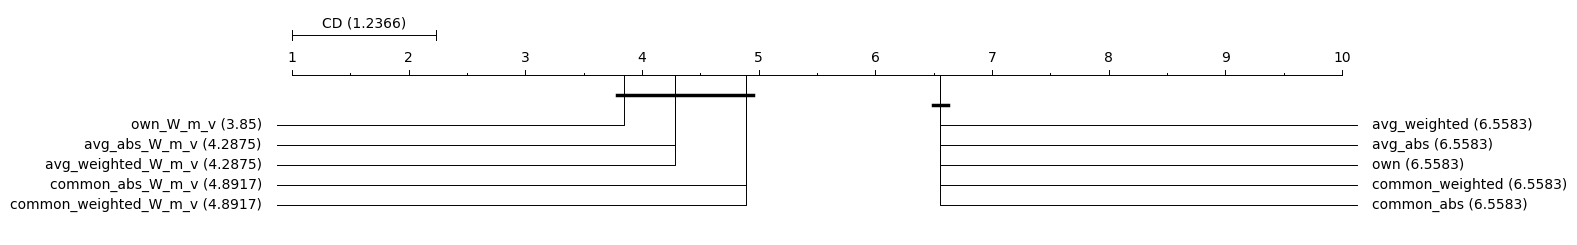

In [42]:

num_cases = f1_results2.shape[0]
ranks_values, critical_distance_nemenyi, figure = nemenyi(rankings, num_cases, alpha)
print(ranks_values)
print(critical_distance_nemenyi)
figure.show()



                                     Comparison  Statistic (Z)       p-value  \
0     common_abs_W_m_v vs common_weighted_W_m_v       0.000000  1.000000e+00   
1                 common_abs_W_m_v vs own_W_m_v       2.665009  7.698627e-03   
2             common_abs_W_m_v vs avg_abs_W_m_v       1.545705  1.221758e-01   
3        common_abs_W_m_v vs avg_weighted_W_m_v       1.545705  1.221758e-01   
4                common_abs_W_m_v vs common_abs       4.264014  2.007866e-05   
5           common_abs_W_m_v vs common_weighted       4.264014  2.007866e-05   
6                       common_abs_W_m_v vs own       4.264014  2.007866e-05   
7                   common_abs_W_m_v vs avg_abs       4.264014  2.007866e-05   
8              common_abs_W_m_v vs avg_weighted       4.264014  2.007866e-05   
9            common_weighted_W_m_v vs own_W_m_v       2.665009  7.698627e-03   
10       common_weighted_W_m_v vs avg_abs_W_m_v       1.545705  1.221758e-01   
11  common_weighted_W_m_v vs avg_weighte

C:\Users\mario\AppData\Local\Temp\ipykernel_26668\844582222.py:3: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  figure.show()


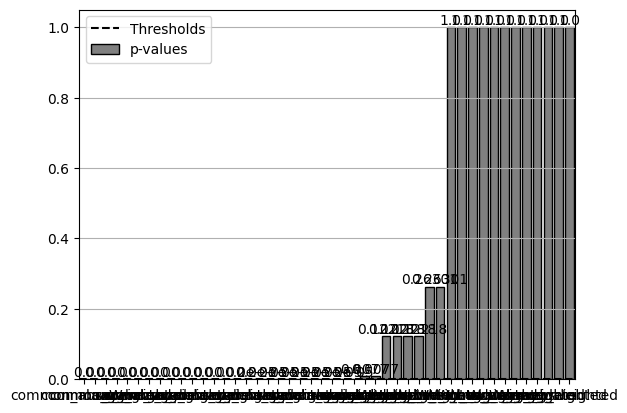

In [43]:

results, figure = bonferroni(rankings, num_cases, alpha, control = None, type_rank = "Friedman")
print(results)
figure.show()


In [44]:

#f1-score
f1_resultsW.columns =f1_resultsW.columns + '_W_m_v'
fullf1_results = pd.concat([f1_resultsW,f1_results],axis=1).reset_index()
rankings, statistic, p_value, critical_value, hypothesis = friedman(fullf1_results, alpha, minimize=False)
print("Overall comparison:\n")
print(hypothesis)
print(f"Statistic {statistic}, p-value {p_value}")
print(rankings)


Overall comparison:

Reject H0 with alpha = 0.05 (Different distributions)
Statistic 159.6431818181818, p-value 9.29505361568772e-11
{'common_abs_W_m_v': 4.958333333333333, 'common_weighted_W_m_v': 4.958333333333333, 'own_W_m_v': 3.8333333333333335, 'avg_abs_W_m_v': 4.229166666666667, 'avg_weighted_W_m_v': 4.229166666666667, 'common_abs': 6.558333333333334, 'common_weighted': 6.558333333333334, 'own': 6.558333333333334, 'avg_abs': 6.558333333333334, 'avg_weighted': 6.558333333333334}


[4.958333333333333, 4.958333333333333, 3.8333333333333335, 4.229166666666667, 4.229166666666667, 6.558333333333334, 6.558333333333334, 6.558333333333334, 6.558333333333334, 6.558333333333334]
1.2365825476883405

C:\Users\mario\AppData\Local\Temp\ipykernel_26668\2903514658.py:5: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  figure.show()


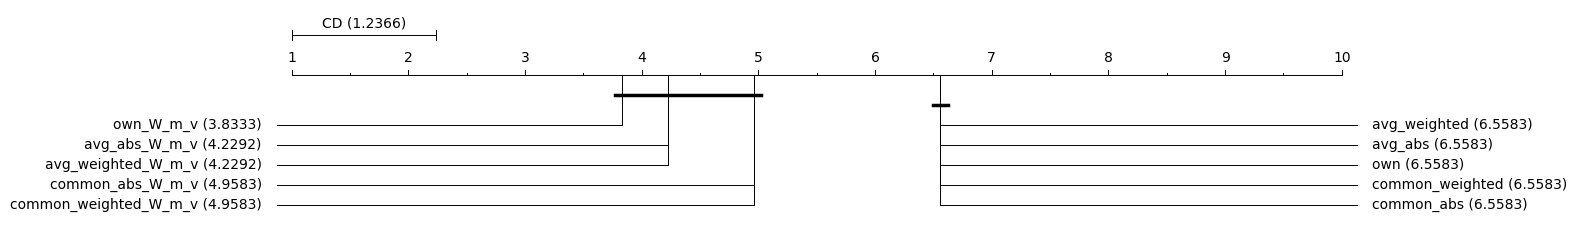

In [45]:

num_cases = f1_results2.shape[0]
ranks_values, critical_distance_nemenyi, figure = nemenyi(rankings, num_cases, alpha)
print(ranks_values)
print(critical_distance_nemenyi)
figure.show()


                                     Comparison  Statistic (Z)       p-value  \
0     common_abs_W_m_v vs common_weighted_W_m_v       0.000000  1.000000e+00   
1                 common_abs_W_m_v vs own_W_m_v       2.878210  3.999392e-03   
2             common_abs_W_m_v vs avg_abs_W_m_v       1.865506  6.211047e-02   
3        common_abs_W_m_v vs avg_weighted_W_m_v       1.865506  6.211047e-02   
4                common_abs_W_m_v vs common_abs       4.093454  4.249949e-05   
5           common_abs_W_m_v vs common_weighted       4.093454  4.249949e-05   
6                       common_abs_W_m_v vs own       4.093454  4.249949e-05   
7                   common_abs_W_m_v vs avg_abs       4.093454  4.249949e-05   
8              common_abs_W_m_v vs avg_weighted       4.093454  4.249949e-05   
9            common_weighted_W_m_v vs own_W_m_v       2.878210  3.999392e-03   
10       common_weighted_W_m_v vs avg_abs_W_m_v       1.865506  6.211047e-02   
11  common_weighted_W_m_v vs avg_weighte

C:\Users\mario\AppData\Local\Temp\ipykernel_26668\2445730000.py:3: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  figure.show()


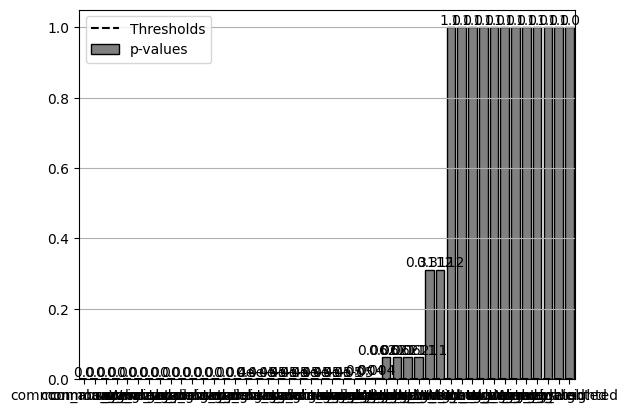

In [46]:

results, figure = bonferroni(rankings, num_cases, alpha, control = None, type_rank = "Friedman")
print(results)
figure.show()

# Non- IID quantity_skew (weighted)

In [47]:
time0 = time.time()
nidd_quantity_skew_resW = experiment2search(data_distribution='niid_quantity_skew',datasets=datasets,distribution_param=0.5)
print("\n[INFO] Total Time (in minutes) =", (time.time() - time0) / 60)
for result in nidd_quantity_skew_resW:
    print(result)

c:\Users\mario\OneDrive\Escritorio\Programs\gitProjects\TFM_EnsembleFL\.venv\Lib\site-packages\sklearn\model_selection\_split.py:737: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(
c:\Users\mario\OneDrive\Escritorio\Programs\gitProjects\TFM_EnsembleFL\.venv\Lib\site-packages\sklearn\model_selection\_split.py:737: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(
c:\Users\mario\OneDrive\Escritorio\Programs\gitProjects\TFM_EnsembleFL\.venv\Lib\site-packages\sklearn\model_selection\_split.py:737: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
c:\Users\mario\OneDrive\Escritorio\Programs\gitProjects\TFM_EnsembleFL\.venv\Lib\site-packages\sklearn\model_selection\_split.py:737: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
c:\Users\mario\O


[INFO] Total Time (in minutes) = 27.237986532847085
FLGlobal_acc  common_abs   c_a_std  common_weighted   c_w_std        own  \
bank           84.679432  1.348826        84.679432  1.348826  84.684347   
adult          79.534876  1.863884        79.535285  1.863319  79.544021   
nursery        87.815158  7.667965        87.865912  7.548032  88.189300   
bcancer        87.262517  6.680048        87.227132  6.695320  87.638942   

FLGlobal_acc   own_std    avg_abs   a_a_std  avg_weighted   a_w_std  
bank          1.359558  84.679432  1.348826     84.679432  1.348826  
adult         1.854740  79.537401  1.861593     79.536446  1.861374  
nursery       7.314143  87.994684  7.467640     88.007030  7.450723  
bcancer       6.597265  87.360739  6.749048     87.380347  6.754047  
FLlocal_acc  common_abs    c_a_std  common_weighted    c_w_std        own  \
bank          85.249272   4.807258        85.249272   4.807258  85.274913   
adult         79.860340   6.283438        79.860340   6.283438

# Accuracy results

In [48]:
_,_,_,_,_,_,acc_results,f1_results = nidd_quantity_skew_resW
acc_results2 = acc_results.round(decimals=3).reset_index()
path = os.path.abspath('') + '\\exp2results\\w_niid_quantityacc'
acc_results2.to_csv(path_or_buf=path)

alpha = 0.05
rankings, statistic, p_value, critical_value, hypothesis = friedman(acc_results2, alpha, minimize=False)
print("Accuracy results:\n")
print(hypothesis)
print(f"Statistic {statistic}, p-value {p_value}")
print(rankings)


Accuracy results:

Reject H0 with alpha = 0.05 (Different distributions)
Statistic 33.289999999999964, p-value 1.0418468392447977e-06
{'common_abs': 3.4458333333333333, 'common_weighted': 3.3208333333333333, 'own': 2.3833333333333333, 'avg_abs': 2.9375, 'avg_weighted': 2.9125}


[3.4458333333333333, 3.3208333333333333, 2.3833333333333333, 2.9375, 2.9125]
0.5568046824928988


C:\Users\mario\AppData\Local\Temp\ipykernel_26668\2379137519.py:5: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  figure.show()


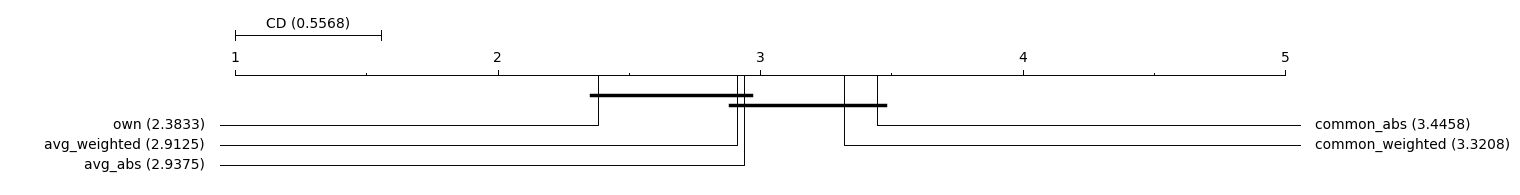

In [49]:


num_cases = acc_results2.shape[0]
ranks_values, critical_distance_nemenyi, figure = nemenyi(rankings, num_cases, alpha)
print(ranks_values)
print(critical_distance_nemenyi)
figure.show()


                        Comparison  Statistic (Z)       p-value  \
0    common_abs vs common_weighted       0.612372  5.402914e-01   
1                common_abs vs own       5.205166  1.938236e-07   
2            common_abs vs avg_abs       2.490315  1.276301e-02   
3       common_abs vs avg_weighted       2.612789  8.980671e-03   
4           common_weighted vs own       4.592793  4.373523e-06   
5       common_weighted vs avg_abs       1.877942  6.038908e-02   
6  common_weighted vs avg_weighted       2.000417  4.545529e-02   
7                   own vs avg_abs       2.714851  6.630557e-03   
8              own vs avg_weighted       2.592377  9.531536e-03   
9          avg_abs vs avg_weighted       0.122474  9.025233e-01   

   Adjusted alpha  Adjusted p-value  alpha            Results  
0           0.005          1.000000   0.05  Fail to Reject H0  
1           0.005          0.000002   0.05          Reject H0  
2           0.005          0.127630   0.05  Fail to Reject H0  
3     

C:\Users\mario\AppData\Local\Temp\ipykernel_26668\844582222.py:3: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  figure.show()


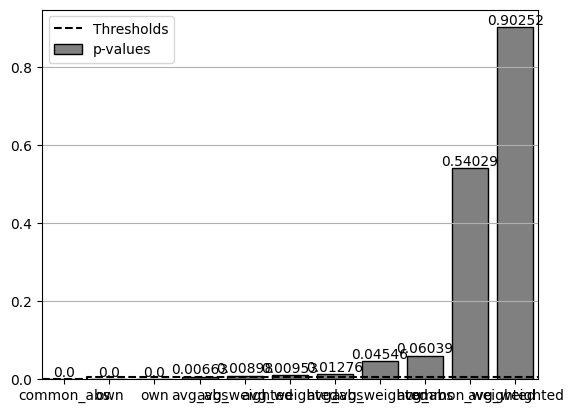

In [50]:

results, figure = bonferroni(rankings, num_cases, alpha, control = None, type_rank = "Friedman")
print(results)
figure.show()


# F1 score statistical test

In [51]:


f1_results2 = f1_results.round(decimals=3).reset_index()
path = os.path.abspath('') + '\\exp2results\\w_niid_quantityf1'
f1_results2.to_csv(path_or_buf=path)

alpha = 0.05
rankings, statistic, p_value, critical_value, hypothesis = friedman(f1_results2, alpha, minimize=False)
print("F1-score results:\n")
print(hypothesis)
print(f"Statistic {statistic}, p-value {p_value}")
print(rankings)


F1-score results:

Reject H0 with alpha = 0.05 (Different distributions)
Statistic 41.328333333333376, p-value 2.302063173420521e-08
{'common_abs': 3.504166666666667, 'common_weighted': 3.3833333333333333, 'own': 2.341666666666667, 'avg_abs': 2.8958333333333335, 'avg_weighted': 2.875}


[3.504166666666667, 3.3833333333333333, 2.341666666666667, 2.8958333333333335, 2.875]
0.5568046824928988


C:\Users\mario\AppData\Local\Temp\ipykernel_26668\2903514658.py:5: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  figure.show()


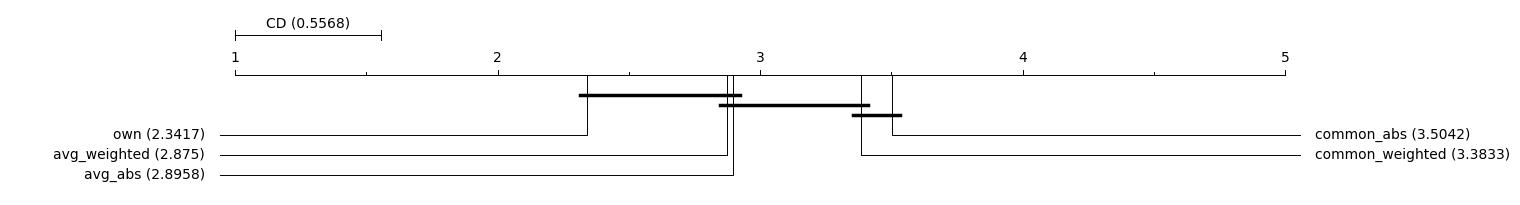

In [52]:

num_cases = f1_results2.shape[0]
ranks_values, critical_distance_nemenyi, figure = nemenyi(rankings, num_cases, alpha)
print(ranks_values)
print(critical_distance_nemenyi)
figure.show()


                        Comparison  Statistic (Z)       p-value  \
0    common_abs vs common_weighted       0.591960  5.538774e-01   
1                common_abs vs own       5.695064  1.233259e-08   
2            common_abs vs avg_abs       2.980213  2.880485e-03   
3       common_abs vs avg_weighted       3.082275  2.054252e-03   
4           common_weighted vs own       5.103104  3.341279e-07   
5       common_weighted vs avg_abs       2.388252  1.692871e-02   
6  common_weighted vs avg_weighted       2.490315  1.276301e-02   
7                   own vs avg_abs       2.714851  6.630557e-03   
8              own vs avg_weighted       2.612789  8.980671e-03   
9          avg_abs vs avg_weighted       0.102062  9.187074e-01   

   Adjusted alpha  Adjusted p-value  alpha            Results  
0           0.005      1.000000e+00   0.05  Fail to Reject H0  
1           0.005      1.233259e-07   0.05          Reject H0  
2           0.005      2.880485e-02   0.05          Reject H0  
3     

C:\Users\mario\AppData\Local\Temp\ipykernel_26668\2445730000.py:3: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  figure.show()


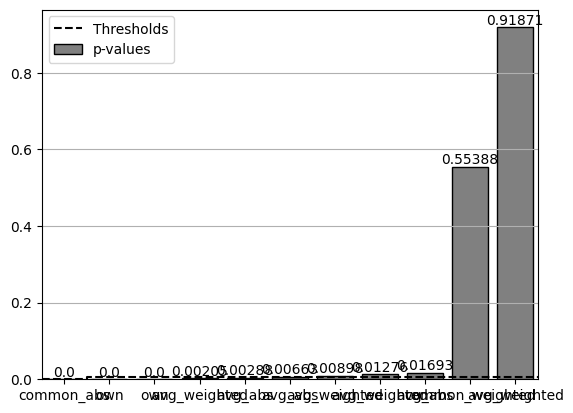

In [53]:

results, figure = bonferroni(rankings, num_cases, alpha, control = None, type_rank = "Friedman")
print(results)
figure.show()

# Non IID- quantity skew (m_v)

In [54]:
time0 = time.time()
nidd_quantity_skew_res = experiment2search(data_distribution='niid_quantity_skew',datasets=datasets,distribution_param=0.5,public_data_prediction='majority_voting')
print("\n[INFO] Total Time (in minutes) =", (time.time() - time0) / 60)
for result in nidd_quantity_skew_res:
    print(result)

c:\Users\mario\OneDrive\Escritorio\Programs\gitProjects\TFM_EnsembleFL\.venv\Lib\site-packages\sklearn\model_selection\_split.py:737: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(
c:\Users\mario\OneDrive\Escritorio\Programs\gitProjects\TFM_EnsembleFL\.venv\Lib\site-packages\sklearn\model_selection\_split.py:737: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(
c:\Users\mario\OneDrive\Escritorio\Programs\gitProjects\TFM_EnsembleFL\.venv\Lib\site-packages\sklearn\model_selection\_split.py:737: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
c:\Users\mario\OneDrive\Escritorio\Programs\gitProjects\TFM_EnsembleFL\.venv\Lib\site-packages\sklearn\model_selection\_split.py:737: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
c:\Users\mario\O


[INFO] Total Time (in minutes) = 18.944051762421925
FLGlobal_acc  common_abs   c_a_std  common_weighted   c_w_std        own  \
bank           84.679432  1.348826        84.679432  1.348826  84.679432   
adult          79.524570  1.891314        79.524570  1.891314  79.524570   
nursery        86.606824  8.492266        86.610254  8.485058  86.595508   
bcancer        86.754218  6.739196        86.754218  6.739196  86.754218   

FLGlobal_acc   own_std    avg_abs   a_a_std  avg_weighted   a_w_std  
bank          1.348826  84.679432  1.348826     84.679432  1.348826  
adult         1.891314  79.524570  1.891314     79.524570  1.891314  
nursery       8.521857  86.599280  8.513998     86.598251  8.516875  
bcancer       6.739196  86.754218  6.739196     86.754218  6.739196  
FLlocal_acc  common_abs    c_a_std  common_weighted    c_w_std        own  \
bank          85.249272   4.807258        85.249272   4.807258  85.249272   
adult         79.860340   6.283438        79.860340   6.283438

# Accuracy results

In [55]:
_,_,_,_,_,_,acc_results,f1_results = nidd_quantity_skew_res
acc_results2 = acc_results.round(decimals=3).reset_index()
path = os.path.abspath('') + '\\exp2results\\niid_quantityacc'
acc_results2.to_csv(path_or_buf=path)

alpha = 0.05
rankings, statistic, p_value, critical_value, hypothesis = friedman(acc_results2, alpha, minimize=False)
print("Accuracy results:\n")
print(hypothesis)
print(f"Statistic {statistic}, p-value {p_value}")
print(rankings)


Accuracy results:

Fail to Reject H0 with alpha = 0.05 (Same distributions)
Statistic 0.07333333333326664, p-value 0.9993439861276204
{'common_abs': 2.9791666666666665, 'common_weighted': 2.9875, 'own': 3.029166666666667, 'avg_abs': 2.995833333333333, 'avg_weighted': 3.0083333333333333}


[2.9791666666666665, 2.9875, 3.029166666666667, 2.995833333333333, 3.0083333333333333]
0.5568046824928988


C:\Users\mario\AppData\Local\Temp\ipykernel_26668\2379137519.py:5: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  figure.show()


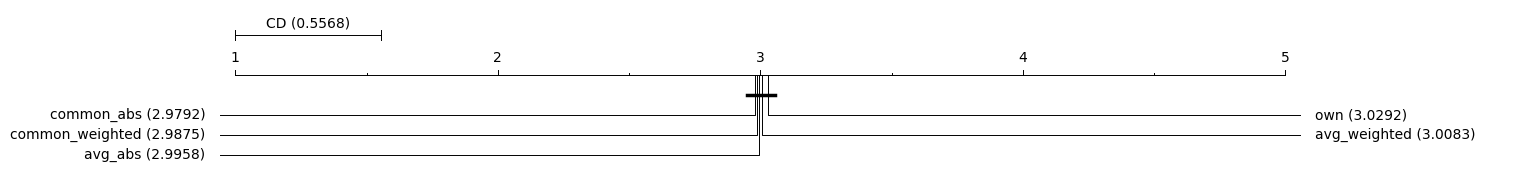

In [56]:


num_cases = acc_results2.shape[0]
ranks_values, critical_distance_nemenyi, figure = nemenyi(rankings, num_cases, alpha)
print(ranks_values)
print(critical_distance_nemenyi)
figure.show()


                        Comparison  Statistic (Z)   p-value  Adjusted alpha  \
0    common_abs vs common_weighted       0.040825  0.967436           0.005   
1                common_abs vs own       0.244949  0.806496           0.005   
2            common_abs vs avg_abs       0.081650  0.934925           0.005   
3       common_abs vs avg_weighted       0.142887  0.886380           0.005   
4           common_weighted vs own       0.204124  0.838256           0.005   
5       common_weighted vs avg_abs       0.040825  0.967436           0.005   
6  common_weighted vs avg_weighted       0.102062  0.918707           0.005   
7                   own vs avg_abs       0.163299  0.870283           0.005   
8              own vs avg_weighted       0.102062  0.918707           0.005   
9          avg_abs vs avg_weighted       0.061237  0.951170           0.005   

   Adjusted p-value  alpha            Results  
0                 1   0.05  Fail to Reject H0  
1                 1   0.05  Fail t

C:\Users\mario\AppData\Local\Temp\ipykernel_26668\844582222.py:3: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  figure.show()


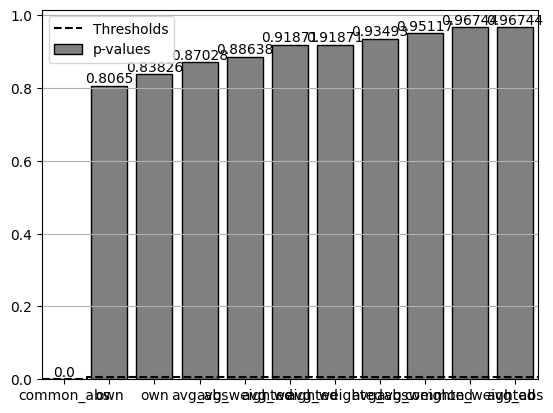

In [57]:

results, figure = bonferroni(rankings, num_cases, alpha, control = None, type_rank = "Friedman")
print(results)
figure.show()


# F1 score statistical test


In [58]:

f1_results2 = f1_results.round(decimals=3).reset_index()
path = os.path.abspath('') + '\\exp2results\\niid_quantityf1'
f1_results2.to_csv(path_or_buf=path)
alpha = 0.05
rankings, statistic, p_value, critical_value, hypothesis = friedman(f1_results2, alpha, minimize=False)
print("F1-score results:\n")
print(hypothesis)
print(f"Statistic {statistic}, p-value {p_value}")
print(rankings)


F1-score results:

Fail to Reject H0 with alpha = 0.05 (Same distributions)
Statistic 0.15833333333330302, p-value 0.9970269001319371
{'common_abs': 3.0125, 'common_weighted': 2.966666666666667, 'own': 3.0416666666666665, 'avg_abs': 2.995833333333333, 'avg_weighted': 2.9833333333333334}


[3.0125, 2.966666666666667, 3.0416666666666665, 2.995833333333333, 2.9833333333333334]
0.5568046824928988


C:\Users\mario\AppData\Local\Temp\ipykernel_26668\2903514658.py:5: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  figure.show()


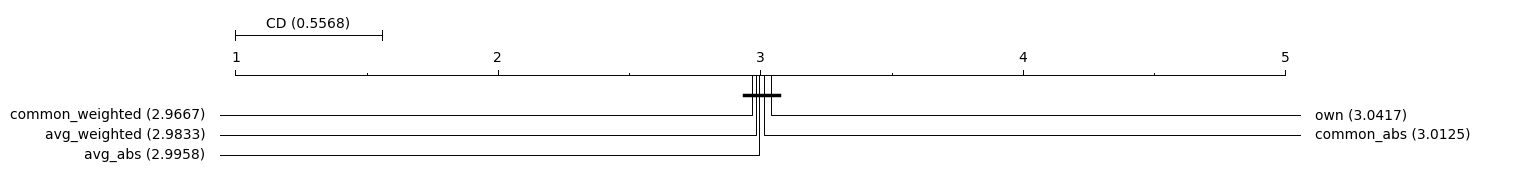

In [59]:

num_cases = f1_results2.shape[0]
ranks_values, critical_distance_nemenyi, figure = nemenyi(rankings, num_cases, alpha)
print(ranks_values)
print(critical_distance_nemenyi)
figure.show()


                        Comparison  Statistic (Z)   p-value  Adjusted alpha  \
0    common_abs vs common_weighted       0.224537  0.822340           0.005   
1                common_abs vs own       0.142887  0.886380           0.005   
2            common_abs vs avg_abs       0.081650  0.934925           0.005   
3       common_abs vs avg_weighted       0.142887  0.886380           0.005   
4           common_weighted vs own       0.367423  0.713303           0.005   
5       common_weighted vs avg_abs       0.142887  0.886380           0.005   
6  common_weighted vs avg_weighted       0.081650  0.934925           0.005   
7                   own vs avg_abs       0.224537  0.822340           0.005   
8              own vs avg_weighted       0.285774  0.775051           0.005   
9          avg_abs vs avg_weighted       0.061237  0.951170           0.005   

   Adjusted p-value  alpha            Results  
0                 1   0.05  Fail to Reject H0  
1                 1   0.05  Fail t

C:\Users\mario\AppData\Local\Temp\ipykernel_26668\2445730000.py:3: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  figure.show()


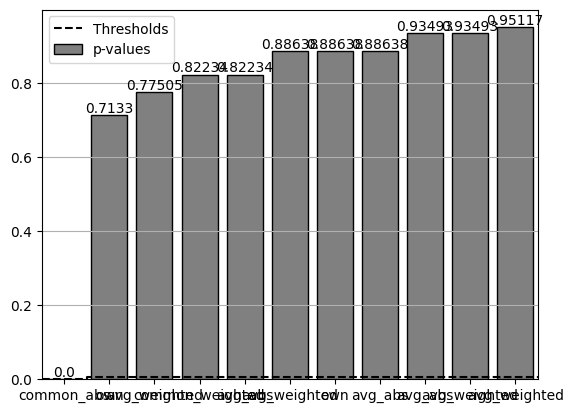

In [60]:

results, figure = bonferroni(rankings, num_cases, alpha, control = None, type_rank = "Friedman")
print(results)
figure.show()

# overall Comparison


In [61]:

# Accuracy
_,_,_,_,_,_,acc_resultsW,f1_resultsW = nidd_quantity_skew_resW
acc_resultsW.columns =acc_resultsW.columns + '_W_m_v'
fullacc_results = pd.concat([acc_resultsW,acc_results],axis=1).reset_index()
alpha = 0.05
rankings, statistic, p_value, critical_value, hypothesis = friedman(fullacc_results, alpha, minimize=False)
print("Overall comparison:\n")
print(hypothesis)
print(f"Statistic {statistic}, p-value {p_value}")
print(rankings)


Overall comparison:

Reject H0 with alpha = 0.05 (Different distributions)
Statistic 130.26499999999987, p-value 8.022260633566702e-11
{'common_abs_W_m_v': 5.05, 'common_weighted_W_m_v': 4.8625, 'own_W_m_v': 3.925, 'avg_abs_W_m_v': 4.458333333333333, 'avg_weighted_W_m_v': 4.4125, 'common_abs': 6.4375, 'common_weighted': 6.445833333333334, 'own': 6.4875, 'avg_abs': 6.454166666666667, 'avg_weighted': 6.466666666666667}


[5.05, 4.8625, 3.925, 4.458333333333333, 4.4125, 6.4375, 6.445833333333334, 6.4875, 6.454166666666667, 6.466666666666667]
1.2365825476883405


C:\Users\mario\AppData\Local\Temp\ipykernel_26668\2954353333.py:5: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  figure.show()


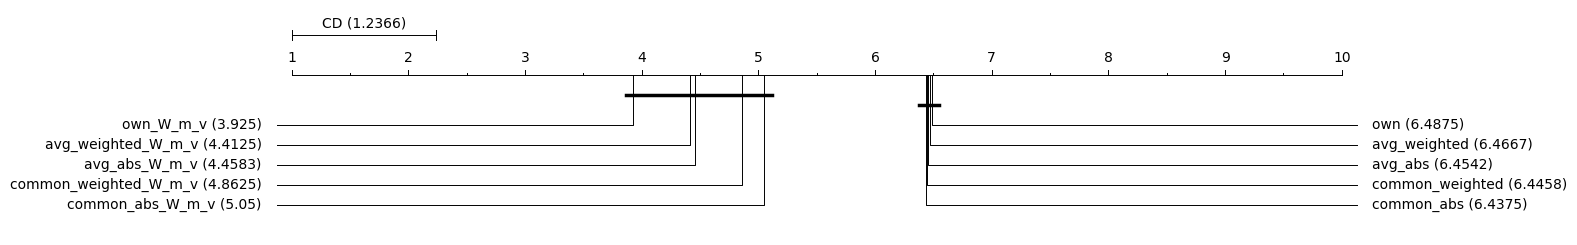

In [62]:


num_cases = f1_results2.shape[0]
ranks_values, critical_distance_nemenyi, figure = nemenyi(rankings, num_cases, alpha)
print(ranks_values)
print(critical_distance_nemenyi)
figure.show()



                                     Comparison  Statistic (Z)       p-value  \
0     common_abs_W_m_v vs common_weighted_W_m_v       0.479702  6.314396e-01   
1                 common_abs_W_m_v vs own_W_m_v       2.878210  3.999392e-03   
2             common_abs_W_m_v vs avg_abs_W_m_v       1.513725  1.300956e-01   
3        common_abs_W_m_v vs avg_weighted_W_m_v       1.630985  1.028934e-01   
4                common_abs_W_m_v vs common_abs       3.549792  3.855357e-04   
5           common_abs_W_m_v vs common_weighted       3.571112  3.554688e-04   
6                       common_abs_W_m_v vs own       3.677712  2.353351e-04   
7                   common_abs_W_m_v vs avg_abs       3.592432  3.276061e-04   
8              common_abs_W_m_v vs avg_weighted       3.624412  2.896194e-04   
9            common_weighted_W_m_v vs own_W_m_v       2.398508  1.646201e-02   
10       common_weighted_W_m_v vs avg_abs_W_m_v       1.034023  3.011252e-01   
11  common_weighted_W_m_v vs avg_weighte

C:\Users\mario\AppData\Local\Temp\ipykernel_26668\844582222.py:3: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  figure.show()


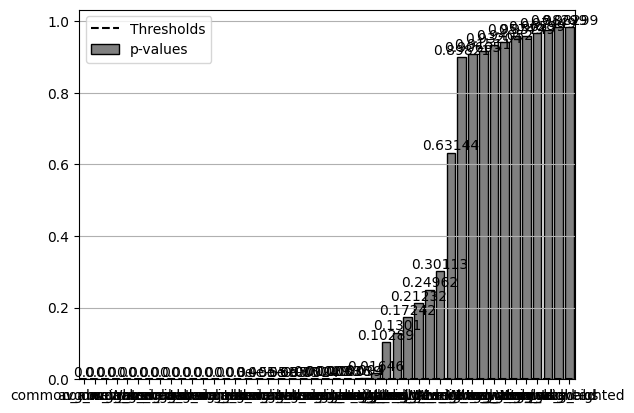

In [63]:

results, figure = bonferroni(rankings, num_cases, alpha, control = None, type_rank = "Friedman")
print(results)
figure.show()


In [64]:

#f1-score
f1_resultsW.columns =f1_resultsW.columns + '_W_m_v'
fullf1_results = pd.concat([f1_resultsW,f1_results],axis=1).reset_index()
rankings, statistic, p_value, critical_value, hypothesis = friedman(fullf1_results, alpha, minimize=False)
print("Overall comparison:\n")
print(hypothesis)
print(f"Statistic {statistic}, p-value {p_value}")
print(rankings)


Overall comparison:

Reject H0 with alpha = 0.05 (Different distributions)
Statistic 152.65545454545463, p-value 1.0751899370831097e-10
{'common_abs_W_m_v': 5.025, 'common_weighted_W_m_v': 4.8625, 'own_W_m_v': 3.779166666666667, 'avg_abs_W_m_v': 4.375, 'avg_weighted_W_m_v': 4.291666666666667, 'common_abs': 6.545833333333333, 'common_weighted': 6.5, 'own': 6.575, 'avg_abs': 6.529166666666667, 'avg_weighted': 6.516666666666667}


[5.025, 4.8625, 3.779166666666667, 4.375, 4.291666666666667, 6.545833333333333, 6.5, 6.575, 6.529166666666667, 6.516666666666667]
1.2365825476883405


C:\Users\mario\AppData\Local\Temp\ipykernel_26668\2903514658.py:5: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  figure.show()


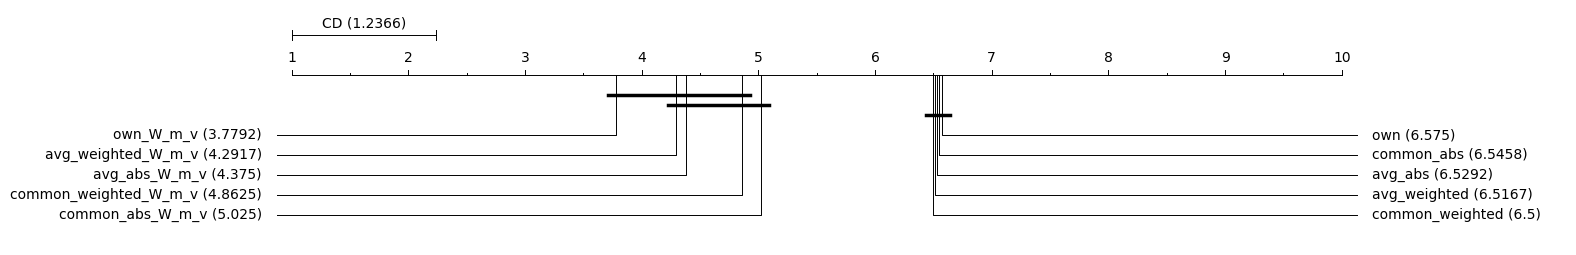

In [65]:

num_cases = f1_results2.shape[0]
ranks_values, critical_distance_nemenyi, figure = nemenyi(rankings, num_cases, alpha)
print(ranks_values)
print(critical_distance_nemenyi)
figure.show()


                                     Comparison  Statistic (Z)       p-value  \
0     common_abs_W_m_v vs common_weighted_W_m_v       0.415741  6.775992e-01   
1                 common_abs_W_m_v vs own_W_m_v       3.187351  1.435826e-03   
2             common_abs_W_m_v vs avg_abs_W_m_v       1.662966  9.631932e-02   
3        common_abs_W_m_v vs avg_weighted_W_m_v       1.876166  6.063245e-02   
4                common_abs_W_m_v vs common_abs       3.890913  9.986771e-05   
5           common_abs_W_m_v vs common_weighted       3.773653  1.608747e-04   
6                       common_abs_W_m_v vs own       3.965533  7.323202e-05   
7                   common_abs_W_m_v vs avg_abs       3.848273  1.189535e-04   
8              common_abs_W_m_v vs avg_weighted       3.816293  1.354717e-04   
9            common_weighted_W_m_v vs own_W_m_v       2.771609  5.577994e-03   
10       common_weighted_W_m_v vs avg_abs_W_m_v       1.247224  2.123153e-01   
11  common_weighted_W_m_v vs avg_weighte

C:\Users\mario\AppData\Local\Temp\ipykernel_26668\2445730000.py:3: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  figure.show()


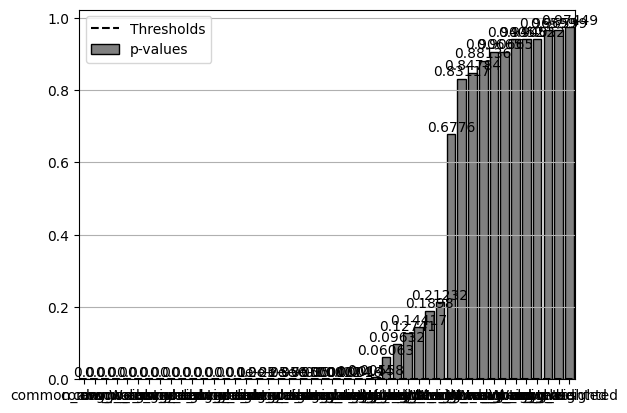

In [66]:

results, figure = bonferroni(rankings, num_cases, alpha, control = None, type_rank = "Friedman")
print(results)
figure.show()

# Non IID dirichlet_label skew (weighted)

In [67]:
time0 = time.time()
nidd_dirichlet_label_resW = experiment2search(data_distribution='niid_dirichlet_label_skew',datasets=datasets,distribution_param=0.5)
print("\n[INFO] Total Time (in minutes) =", (time.time() - time0) / 60)
for result in nidd_dirichlet_label_resW:
    print(result)

c:\Users\mario\OneDrive\Escritorio\Programs\gitProjects\TFM_EnsembleFL\.venv\Lib\site-packages\sklearn\model_selection\_split.py:737: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(
c:\Users\mario\OneDrive\Escritorio\Programs\gitProjects\TFM_EnsembleFL\.venv\Lib\site-packages\sklearn\model_selection\_split.py:737: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(
c:\Users\mario\OneDrive\Escritorio\Programs\gitProjects\TFM_EnsembleFL\.venv\Lib\site-packages\sklearn\model_selection\_split.py:737: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
c:\Users\mario\OneDrive\Escritorio\Programs\gitProjects\TFM_EnsembleFL\.venv\Lib\site-packages\sklearn\model_selection\_split.py:737: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
c:\Users\mario\O


[INFO] Total Time (in minutes) = 23.84584370851517
FLGlobal_acc  common_abs    c_a_std  common_weighted    c_w_std        own  \
bank           76.720296  21.623106        76.743742  21.558825  76.708941   
adult          71.222768  17.529727        71.301324  17.412091  70.864524   
nursery        68.705590  21.272131        68.953361  21.183825  68.851680   
bcancer        71.536069  19.678475        71.367715  19.752583  70.831509   

FLGlobal_acc    own_std    avg_abs    a_a_std  avg_weighted    a_w_std  
bank          21.738099  76.694638  21.730548     76.698963  21.716233  
adult         18.150396  71.070025  17.742621     71.107699  17.663347  
nursery       21.493221  68.784979  21.332496     68.806927  21.347326  
bcancer       19.465727  71.461514  19.627942     71.375467  19.696153  
FLlocal_acc  common_abs    c_a_std  common_weighted    c_w_std        own  \
bank          88.764243   9.664551        88.768226   9.670162  88.814192   
adult         86.540893  10.473943    

# Accuracy results

In [68]:
_,_,_,_,_,_,acc_results,f1_results = nidd_dirichlet_label_resW
acc_results2 = acc_results.round(decimals=3).reset_index()
path = os.path.abspath('') + '\\exp2results\\w_niid_dirichlet_labelacc'
acc_results2.to_csv(path_or_buf=path)

alpha = 0.05
rankings, statistic, p_value, critical_value, hypothesis = friedman(acc_results2, alpha, minimize=False)
print("Accuracy results:\n")
print(hypothesis)
print(f"Statistic {statistic}, p-value {p_value}")
print(rankings)


Accuracy results:

Reject H0 with alpha = 0.05 (Different distributions)
Statistic 38.74000000000024, p-value 7.886153263747531e-08
{'common_abs': 3.095833333333333, 'common_weighted': 2.275, 'own': 3.2958333333333334, 'avg_abs': 3.4208333333333334, 'avg_weighted': 2.9125}


[3.095833333333333, 2.275, 3.2958333333333334, 3.4208333333333334, 2.9125]
0.5568046824928988


C:\Users\mario\AppData\Local\Temp\ipykernel_26668\2379137519.py:5: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  figure.show()


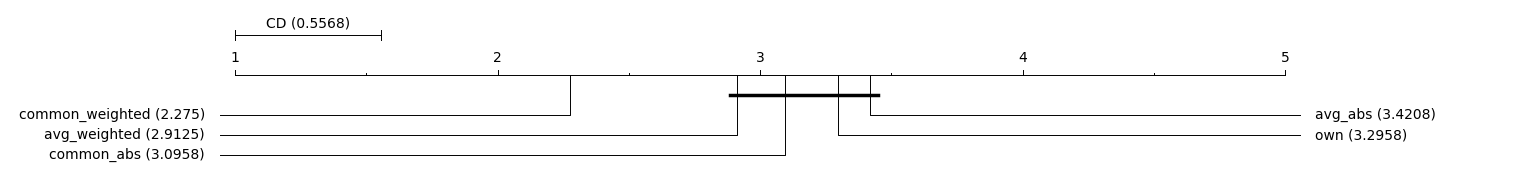

In [69]:


num_cases = acc_results2.shape[0]
ranks_values, critical_distance_nemenyi, figure = nemenyi(rankings, num_cases, alpha)
print(ranks_values)
print(critical_distance_nemenyi)
figure.show()


                        Comparison  Statistic (Z)       p-value  \
0    common_abs vs common_weighted       4.021246  5.789119e-05   
1                common_abs vs own       0.979796  3.271869e-01   
2            common_abs vs avg_abs       1.592168  1.113469e-01   
3       common_abs vs avg_weighted       0.898146  3.691076e-01   
4           common_weighted vs own       5.001042  5.702142e-07   
5       common_weighted vs avg_abs       5.613414  1.983732e-08   
6  common_weighted vs avg_weighted       3.123099  1.789573e-03   
7                   own vs avg_abs       0.612372  5.402914e-01   
8              own vs avg_weighted       1.877942  6.038908e-02   
9          avg_abs vs avg_weighted       2.490315  1.276301e-02   

   Adjusted alpha  Adjusted p-value  alpha            Results  
0           0.005      5.789119e-04   0.05          Reject H0  
1           0.005      1.000000e+00   0.05  Fail to Reject H0  
2           0.005      1.000000e+00   0.05  Fail to Reject H0  
3     

C:\Users\mario\AppData\Local\Temp\ipykernel_26668\844582222.py:3: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  figure.show()


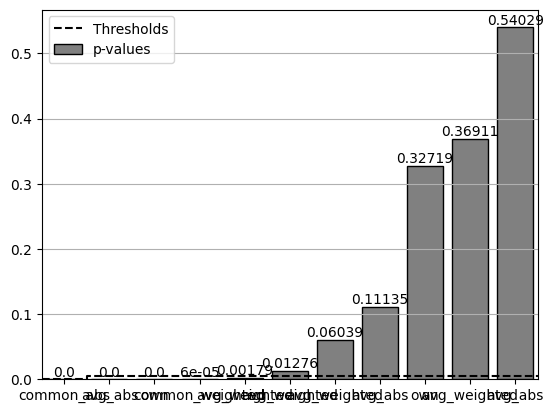

In [70]:

results, figure = bonferroni(rankings, num_cases, alpha, control = None, type_rank = "Friedman")
print(results)
figure.show()


# F1 score statistical test


In [71]:

f1_results2 = f1_results.round(decimals=3).reset_index()
path = os.path.abspath('') + '\\exp2results\\w_niid_dirichlet_labelf1'
f1_results2.to_csv(path_or_buf=path)
alpha = 0.05
rankings, statistic, p_value, critical_value, hypothesis = friedman(f1_results2, alpha, minimize=False)
print("F1-score results:\n")
print(hypothesis)
print(f"Statistic {statistic}, p-value {p_value}")
print(rankings)


F1-score results:

Reject H0 with alpha = 0.05 (Different distributions)
Statistic 30.646666666666988, p-value 3.613867191609721e-06
{'common_abs': 3.529166666666667, 'common_weighted': 2.5458333333333334, 'own': 2.775, 'avg_abs': 3.2875, 'avg_weighted': 2.8625}


[3.529166666666667, 2.5458333333333334, 2.775, 3.2875, 2.8625]
0.5568046824928988


C:\Users\mario\AppData\Local\Temp\ipykernel_26668\2903514658.py:5: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  figure.show()


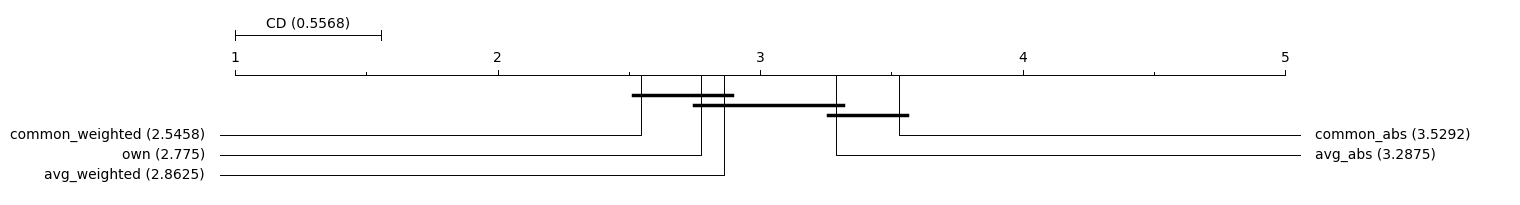

In [72]:

num_cases = f1_results2.shape[0]
ranks_values, critical_distance_nemenyi, figure = nemenyi(rankings, num_cases, alpha)
print(ranks_values)
print(critical_distance_nemenyi)
figure.show()


                        Comparison  Statistic (Z)   p-value  Adjusted alpha  \
0    common_abs vs common_weighted       4.817330  0.000001           0.005   
1                common_abs vs own       3.694647  0.000220           0.005   
2            common_abs vs avg_abs       1.183920  0.236445           0.005   
3       common_abs vs avg_weighted       3.265986  0.001091           0.005   
4           common_weighted vs own       1.122683  0.261572           0.005   
5       common_weighted vs avg_abs       3.633410  0.000280           0.005   
6  common_weighted vs avg_weighted       1.551344  0.120819           0.005   
7                   own vs avg_abs       2.510727  0.012048           0.005   
8              own vs avg_weighted       0.428661  0.668170           0.005   
9          avg_abs vs avg_weighted       2.082066  0.037336           0.005   

   Adjusted p-value  alpha            Results  
0          0.000015   0.05          Reject H0  
1          0.002202   0.05        

C:\Users\mario\AppData\Local\Temp\ipykernel_26668\2445730000.py:3: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  figure.show()


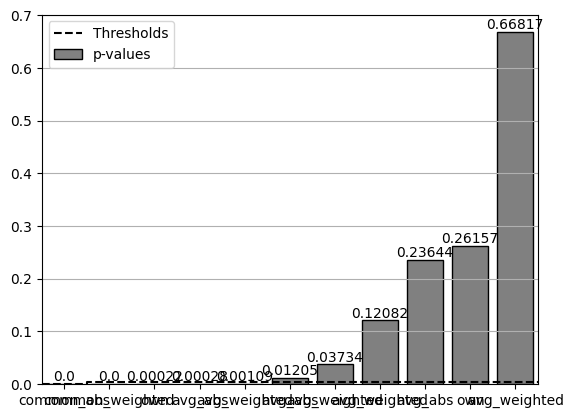

In [73]:

results, figure = bonferroni(rankings, num_cases, alpha, control = None, type_rank = "Friedman")
print(results)
figure.show()

# Non IID dirichlet label skew (m_v)

In [74]:
time0 = time.time()
nidd_dirichlet_label_res = experiment2search(data_distribution='niid_dirichlet_label_skew',datasets=datasets,distribution_param=0.5,public_data_prediction='majority_voting')
print("\n[INFO] Total Time (in minutes) =", (time.time() - time0) / 60)
for result in nidd_dirichlet_label_res:
    print(result)

c:\Users\mario\OneDrive\Escritorio\Programs\gitProjects\TFM_EnsembleFL\.venv\Lib\site-packages\sklearn\model_selection\_split.py:737: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(
c:\Users\mario\OneDrive\Escritorio\Programs\gitProjects\TFM_EnsembleFL\.venv\Lib\site-packages\sklearn\model_selection\_split.py:737: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(
c:\Users\mario\OneDrive\Escritorio\Programs\gitProjects\TFM_EnsembleFL\.venv\Lib\site-packages\sklearn\model_selection\_split.py:737: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
c:\Users\mario\OneDrive\Escritorio\Programs\gitProjects\TFM_EnsembleFL\.venv\Lib\site-packages\sklearn\model_selection\_split.py:737: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
c:\Users\mario\O


[INFO] Total Time (in minutes) = 17.98252372344335
FLGlobal_acc  common_abs    c_a_std  common_weighted    c_w_std        own  \
bank           76.706287  21.666740        76.744529  21.556397  76.689182   
adult          71.405815  17.402916        71.443011  17.350999  71.044431   
nursery        73.665295  18.528468        73.750000  18.404579  73.323045   
bcancer        74.669539  16.244785        74.669539  16.244785  74.055996   

FLGlobal_acc    own_std    avg_abs    a_a_std  avg_weighted    a_w_std  
bank          21.727616  76.685889  21.725866     76.691639  21.709585  
adult         17.780752  71.190895  17.709666     71.178474  17.713081  
nursery       18.850694  73.507030  18.608811     73.545267  18.571303  
bcancer       16.975885  74.614637  16.335784     74.614637  16.335784  
FLlocal_acc  common_abs    c_a_std  common_weighted    c_w_std        own  \
bank          88.745093   9.682599        88.747272   9.681672  88.764947   
adult         86.460442  10.421825    

# Accuracy results

In [75]:
_,_,_,_,_,_,acc_results,f1_results = nidd_dirichlet_label_res
acc_results2 = acc_results.round(decimals=3).reset_index()
path = os.path.abspath('') + '\\exp2results\\niid_dirichlet_labelacc'
acc_results2.to_csv(path_or_buf=path)
alpha = 0.05
rankings, statistic, p_value, critical_value, hypothesis = friedman(acc_results2, alpha, minimize=False)
print("Accuracy results:\n")
print(hypothesis)
print(f"Statistic {statistic}, p-value {p_value}")
print(rankings)



Accuracy results:

Reject H0 with alpha = 0.05 (Different distributions)
Statistic 27.215000000000146, p-value 1.79851515110796e-05
{'common_abs': 2.8541666666666665, 'common_weighted': 2.4291666666666667, 'own': 3.4166666666666665, 'avg_abs': 3.175, 'avg_weighted': 3.125}


[2.8541666666666665, 2.4291666666666667, 3.4166666666666665, 3.175, 3.125]
0.5568046824928988


C:\Users\mario\AppData\Local\Temp\ipykernel_26668\3434521576.py:5: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  figure.show()


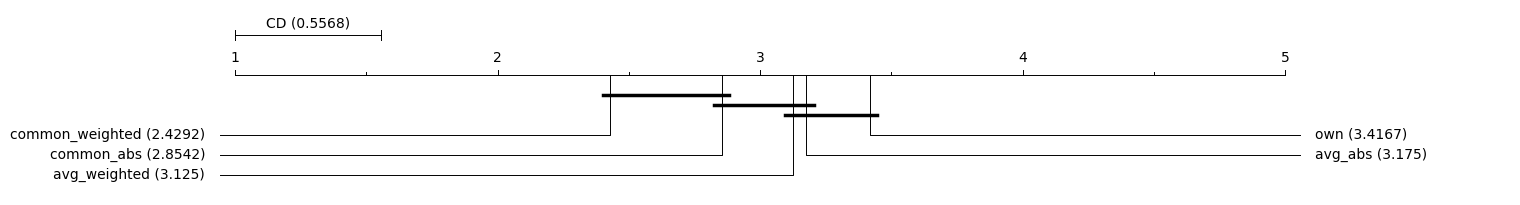

In [76]:

num_cases = acc_results2.shape[0]
ranks_values, critical_distance_nemenyi, figure = nemenyi(rankings, num_cases, alpha)
print(ranks_values)
print(critical_distance_nemenyi)
figure.show()


                        Comparison  Statistic (Z)   p-value  Adjusted alpha  \
0    common_abs vs common_weighted       2.082066  0.037336           0.005   
1                common_abs vs own       2.755676  0.005857           0.005   
2            common_abs vs avg_abs       1.571756  0.116007           0.005   
3       common_abs vs avg_weighted       1.326807  0.184573           0.005   
4           common_weighted vs own       4.837742  0.000001           0.005   
5       common_weighted vs avg_abs       3.653822  0.000258           0.005   
6  common_weighted vs avg_weighted       3.408873  0.000652           0.005   
7                   own vs avg_abs       1.183920  0.236445           0.005   
8              own vs avg_weighted       1.428869  0.153042           0.005   
9          avg_abs vs avg_weighted       0.244949  0.806496           0.005   

   Adjusted p-value  alpha            Results  
0          0.373364   0.05  Fail to Reject H0  
1          0.058571   0.05  Fail t

C:\Users\mario\AppData\Local\Temp\ipykernel_26668\844582222.py:3: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  figure.show()


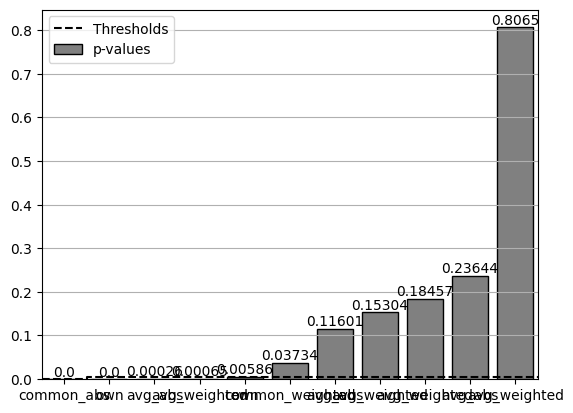

In [77]:

results, figure = bonferroni(rankings, num_cases, alpha, control = None, type_rank = "Friedman")
print(results)
figure.show()



# F1 score statistical test


In [78]:

f1_results2 = f1_results.round(decimals=3).reset_index()
path = os.path.abspath('') + '\\exp2results\\niid_dirichlet_labelf1'
f1_results2.to_csv(path_or_buf=path)
alpha = 0.05
rankings, statistic, p_value, critical_value, hypothesis = friedman(f1_results2, alpha, minimize=False)
print("F1-score results:\n")
print(hypothesis)
print(f"Statistic {statistic}, p-value {p_value}")
print(rankings)


F1-score results:

Fail to Reject H0 with alpha = 0.05 (Same distributions)
Statistic 3.6649999999999636, p-value 0.45323692087607637
{'common_abs': 3.0416666666666665, 'common_weighted': 2.754166666666667, 'own': 3.0541666666666667, 'avg_abs': 3.075, 'avg_weighted': 3.075}


[3.0416666666666665, 2.754166666666667, 3.0541666666666667, 3.075, 3.075]
0.5568046824928988


C:\Users\mario\AppData\Local\Temp\ipykernel_26668\2903514658.py:5: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  figure.show()


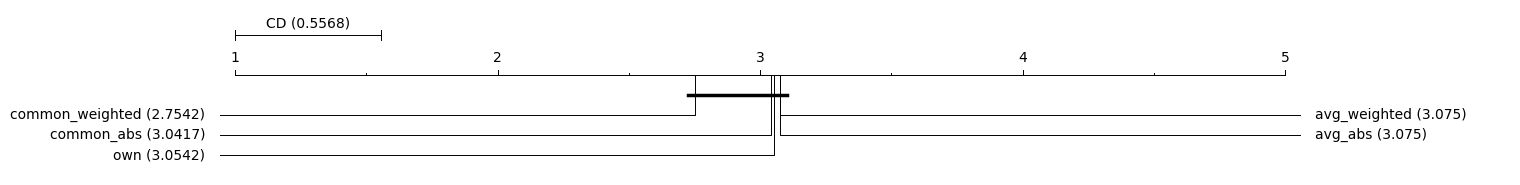

In [79]:

num_cases = f1_results2.shape[0]
ranks_values, critical_distance_nemenyi, figure = nemenyi(rankings, num_cases, alpha)
print(ranks_values)
print(critical_distance_nemenyi)
figure.show()


                        Comparison  Statistic (Z)   p-value  Adjusted alpha  \
0    common_abs vs common_weighted       1.408457  0.158996           0.005   
1                common_abs vs own       0.061237  0.951170           0.005   
2            common_abs vs avg_abs       0.163299  0.870283           0.005   
3       common_abs vs avg_weighted       0.163299  0.870283           0.005   
4           common_weighted vs own       1.469694  0.141645           0.005   
5       common_weighted vs avg_abs       1.571756  0.116007           0.005   
6  common_weighted vs avg_weighted       1.571756  0.116007           0.005   
7                   own vs avg_abs       0.102062  0.918707           0.005   
8              own vs avg_weighted       0.102062  0.918707           0.005   
9          avg_abs vs avg_weighted       0.000000  1.000000           0.005   

   Adjusted p-value  alpha            Results  
0                 1   0.05  Fail to Reject H0  
1                 1   0.05  Fail t

C:\Users\mario\AppData\Local\Temp\ipykernel_26668\2445730000.py:3: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  figure.show()


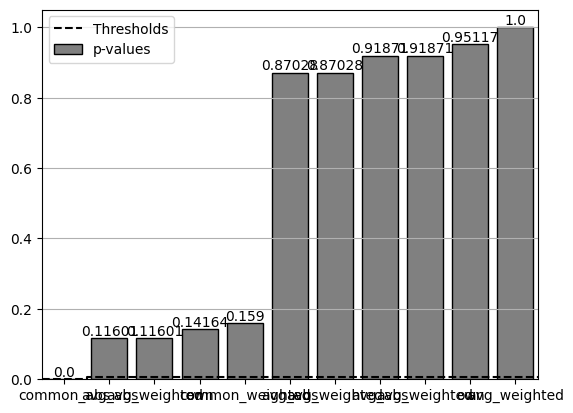

In [80]:

results, figure = bonferroni(rankings, num_cases, alpha, control = None, type_rank = "Friedman")
print(results)
figure.show()

# overall Comparison


In [81]:

# Accuracy
_,_,_,_,_,_,acc_resultsW,f1_resultsW = nidd_dirichlet_label_resW
acc_resultsW.columns =acc_resultsW.columns + '_W_m_v'
fullacc_results = pd.concat([acc_resultsW,acc_results],axis=1).reset_index()
alpha = 0.05
rankings, statistic, p_value, critical_value, hypothesis = friedman(fullacc_results, alpha, minimize=False)
print("Overall comparison:\n")
print(hypothesis)
print(f"Statistic {statistic}, p-value {p_value}")
print(rankings)


Overall comparison:

Reject H0 with alpha = 0.05 (Different distributions)
Statistic 201.3722727272725, p-value 8.842437893008537e-11
{'common_abs_W_m_v': 6.595833333333333, 'common_weighted_W_m_v': 5.566666666666666, 'own_W_m_v': 6.929166666666666, 'avg_abs_W_m_v': 7.191666666666666, 'avg_weighted_W_m_v': 6.670833333333333, 'common_abs': 4.104166666666667, 'common_weighted': 3.370833333333333, 'own': 5.191666666666666, 'avg_abs': 4.766666666666667, 'avg_weighted': 4.6125}


[6.595833333333333, 5.566666666666666, 6.929166666666666, 7.191666666666666, 6.670833333333333, 4.104166666666667, 3.370833333333333, 5.191666666666666, 4.766666666666667, 4.6125]
1.2365825476883405


C:\Users\mario\AppData\Local\Temp\ipykernel_26668\784648252.py:5: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  figure.show()


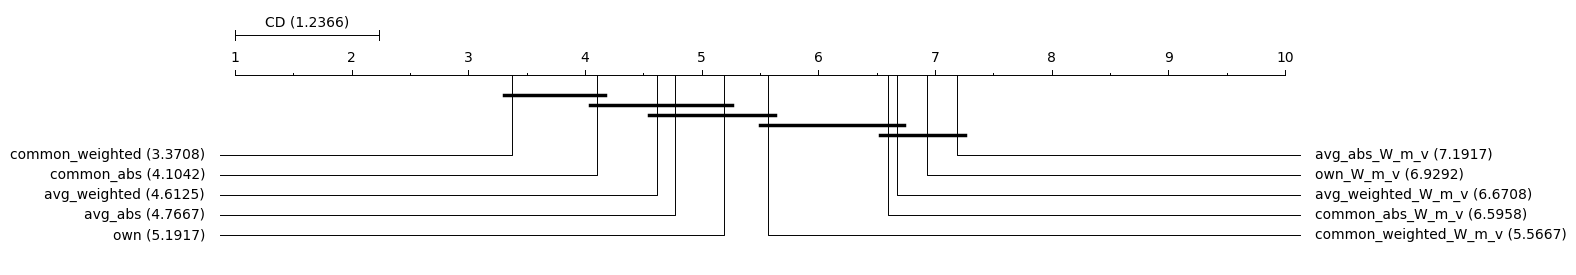

In [82]:


num_cases = f1_results2.shape[0]
ranks_values, critical_distance_nemenyi, figure = nemenyi(rankings, num_cases, alpha)
print(ranks_values)
print(critical_distance_nemenyi)
figure.show()


                                     Comparison  Statistic (Z)       p-value  \
0     common_abs_W_m_v vs common_weighted_W_m_v       2.633029  8.462716e-03   
1                 common_abs_W_m_v vs own_W_m_v       0.852803  3.937686e-01   
2             common_abs_W_m_v vs avg_abs_W_m_v       1.524385  1.274125e-01   
3        common_abs_W_m_v vs avg_weighted_W_m_v       0.191881  8.478357e-01   
4                common_abs_W_m_v vs common_abs       6.374701  1.833196e-10   
5           common_abs_W_m_v vs common_weighted       8.250868  0.000000e+00   
6                       common_abs_W_m_v vs own       3.592432  3.276061e-04   
7                   common_abs_W_m_v vs avg_abs       4.679756  2.872169e-06   
8              common_abs_W_m_v vs avg_weighted       5.074177  3.891766e-07   
9            common_weighted_W_m_v vs own_W_m_v       3.485832  4.906095e-04   
10       common_weighted_W_m_v vs avg_abs_W_m_v       4.157414  3.218704e-05   
11  common_weighted_W_m_v vs avg_weighte

C:\Users\mario\AppData\Local\Temp\ipykernel_26668\2222414530.py:3: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  figure.show()


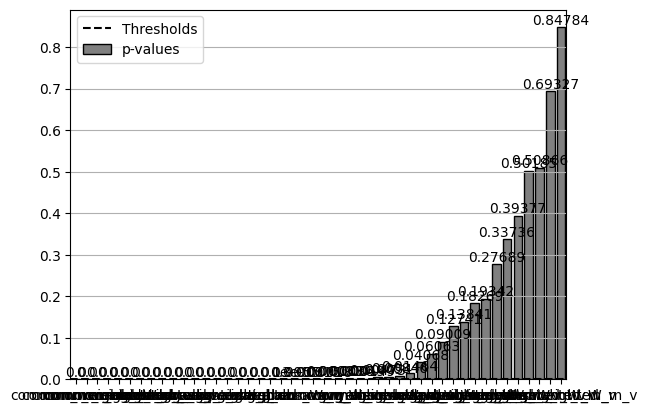

In [83]:


results, figure = bonferroni(rankings, num_cases, alpha, control = None, type_rank = "Friedman")
print(results)
figure.show()


In [84]:

#f1-score
f1_resultsW.columns =f1_resultsW.columns + '_W_m_v'
fullf1_results = pd.concat([f1_resultsW,f1_results],axis=1).reset_index()
rankings, statistic, p_value, critical_value, hypothesis = friedman(fullf1_results, alpha, minimize=False)
print("Overall comparison:\n")
print(hypothesis)
print(f"Statistic {statistic}, p-value {p_value}")
print(rankings)


Overall comparison:

Reject H0 with alpha = 0.05 (Different distributions)
Statistic 51.38500000000022, p-value 5.9107049810158685e-08
{'common_abs_W_m_v': 6.770833333333333, 'common_weighted_W_m_v': 5.4875, 'own_W_m_v': 5.541666666666667, 'avg_abs_W_m_v': 6.2875, 'avg_weighted_W_m_v': 5.875, 'common_abs': 5.095833333333333, 'common_weighted': 4.5, 'own': 5.0625, 'avg_abs': 5.183333333333334, 'avg_weighted': 5.195833333333334}


[6.770833333333333, 5.4875, 5.541666666666667, 6.2875, 5.875, 5.095833333333333, 4.5, 5.0625, 5.183333333333334, 5.195833333333334]
1.2365825476883405


C:\Users\mario\AppData\Local\Temp\ipykernel_26668\2903514658.py:5: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  figure.show()


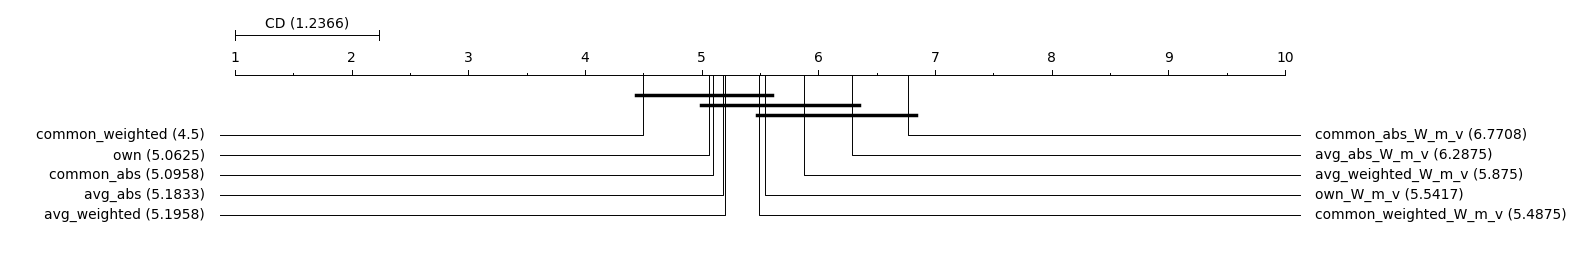

In [85]:

num_cases = f1_results2.shape[0]
ranks_values, critical_distance_nemenyi, figure = nemenyi(rankings, num_cases, alpha)
print(ranks_values)
print(critical_distance_nemenyi)
figure.show()


                                     Comparison  Statistic (Z)       p-value  \
0     common_abs_W_m_v vs common_weighted_W_m_v       3.283291  1.026027e-03   
1                 common_abs_W_m_v vs own_W_m_v       3.144711  1.662512e-03   
2             common_abs_W_m_v vs avg_abs_W_m_v       1.236564  2.162489e-01   
3        common_abs_W_m_v vs avg_weighted_W_m_v       2.291908  2.191097e-02   
4                common_abs_W_m_v vs common_abs       4.285334  1.824645e-05   
5           common_abs_W_m_v vs common_weighted       5.809720  6.257759e-09   
6                       common_abs_W_m_v vs own       4.370615  1.238973e-05   
7                   common_abs_W_m_v vs avg_abs       4.061474  4.876392e-05   
8              common_abs_W_m_v vs avg_weighted       4.029494  5.589715e-05   
9            common_weighted_W_m_v vs own_W_m_v       0.138580  8.897817e-01   
10       common_weighted_W_m_v vs avg_abs_W_m_v       2.046727  4.068491e-02   
11  common_weighted_W_m_v vs avg_weighte

C:\Users\mario\AppData\Local\Temp\ipykernel_26668\2445730000.py:3: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  figure.show()


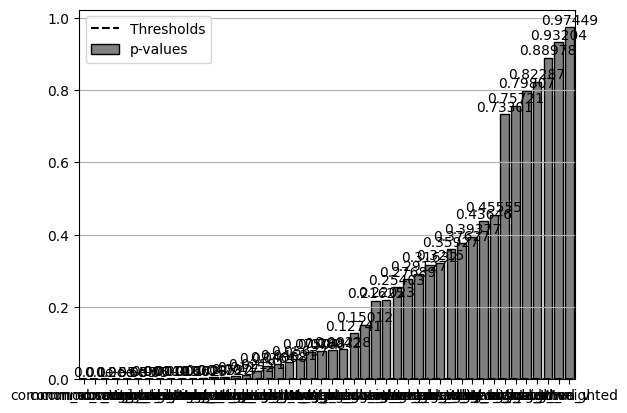

In [86]:

results, figure = bonferroni(rankings, num_cases, alpha, control = None, type_rank = "Friedman")
print(results)
figure.show()

# Non IID label quantity skew (weighted)

In [87]:
dataset = {'nursery':(X_data_nursery,targets_nursery)} #Only nursery bc it is the only one with more than 2 labels
time0 = time.time()
nidd_label_quantity_resW = experiment2search(data_distribution='niid_label_quantity_skew',datasets=dataset,distribution_param=3)
print("\n[INFO] Total Time (in minutes) =", (time.time() - time0) / 60)
for result in nidd_label_quantity_resW:
    print(result)

c:\Users\mario\OneDrive\Escritorio\Programs\gitProjects\TFM_EnsembleFL\.venv\Lib\site-packages\sklearn\model_selection\_split.py:737: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(


c:\Users\mario\OneDrive\Escritorio\Programs\gitProjects\TFM_EnsembleFL\.venv\Lib\site-packages\sklearn\model_selection\_split.py:737: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(
c:\Users\mario\OneDrive\Escritorio\Programs\gitProjects\TFM_EnsembleFL\.venv\Lib\site-packages\sklearn\model_selection\_split.py:737: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
c:\Users\mario\OneDrive\Escritorio\Programs\gitProjects\TFM_EnsembleFL\.venv\Lib\site-packages\sklearn\model_selection\_split.py:737: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
c:\Users\mario\OneDrive\Escritorio\Programs\gitProjects\TFM_EnsembleFL\.venv\Lib\site-packages\sklearn\model_selection\_split.py:737: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
c:\Users\mario\O


[INFO] Total Time (in minutes) = 3.698272200425466
FLGlobal_acc  common_abs    c_a_std  common_weighted    c_w_std        own  \
nursery        54.631001  21.186183        54.609911  21.194109  54.699246   

FLGlobal_acc    own_std    avg_abs    a_a_std  avg_weighted    a_w_std  
nursery       21.275548  54.612826  21.181979     54.595679  21.196105  
FLlocal_acc  common_abs   c_a_std  common_weighted   c_w_std        own  \
nursery       95.357816  4.569582        95.325594  4.596739  95.253798   

FLlocal_acc   own_std    avg_abs   a_a_std  avg_weighted   a_w_std  
nursery      4.600746  95.342502  4.584871     95.279085  4.623152  
centralized_acc       mean       std
nursery          99.128944  0.350885
FLGlobal_f1  common_abs  c_a_std  common_weighted    c_w_std        own  \
nursery       65.168212   18.781        65.163962  18.785464  65.162821   

FLGlobal_f1    own_std    avg_abs    a_a_std  avg_weighted    a_w_std  
nursery      18.797002  65.161649  18.780044     65.152892 

# Accuracy results

In [88]:
_,_,_,_,_,_,acc_results,f1_results = nidd_label_quantity_resW
acc_results2 = acc_results.round(decimals=3).reset_index()
path = os.path.abspath('') + '\\exp2results\\w_niid_dirichlet_quantityacc'
acc_results2.to_csv(path_or_buf=path)
alpha = 0.05
rankings, statistic, p_value, critical_value, hypothesis = friedman(acc_results2, alpha, minimize=False)
print("Accuracy results:\n")
print(hypothesis)
print(f"Statistic {statistic}, p-value {p_value}")
print(rankings)


Accuracy results:

Fail to Reject H0 with alpha = 0.05 (Same distributions)
Statistic 6.153333333333421, p-value 0.18798614689010174
{'common_abs': 2.466666666666667, 'common_weighted': 3.0, 'own': 2.8833333333333333, 'avg_abs': 3.283333333333333, 'avg_weighted': 3.3666666666666667}


[2.466666666666667, 3.0, 2.8833333333333333, 3.283333333333333, 3.3666666666666667]
1.1136093649857977


C:\Users\mario\AppData\Local\Temp\ipykernel_26668\2379137519.py:5: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  figure.show()


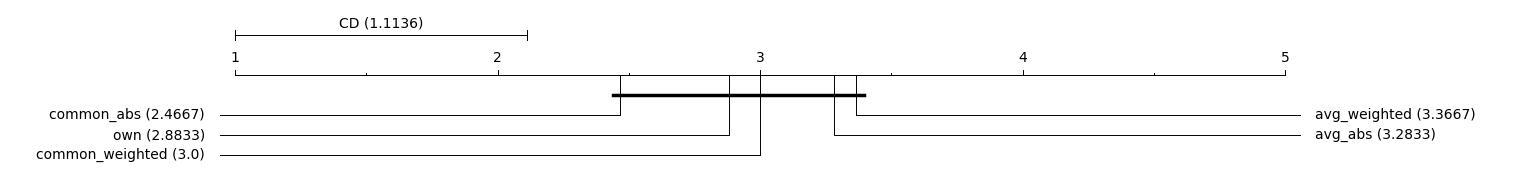

In [89]:


num_cases = acc_results2.shape[0]
ranks_values, critical_distance_nemenyi, figure = nemenyi(rankings, num_cases, alpha)
print(ranks_values)
print(critical_distance_nemenyi)
figure.show()


                        Comparison  Statistic (Z)   p-value  Adjusted alpha  \
0    common_abs vs common_weighted       1.306395  0.191418           0.005   
1                common_abs vs own       1.020621  0.307434           0.005   
2            common_abs vs avg_abs       2.000417  0.045455           0.005   
3       common_abs vs avg_weighted       2.204541  0.027486           0.005   
4           common_weighted vs own       0.285774  0.775051           0.005   
5       common_weighted vs avg_abs       0.694022  0.487668           0.005   
6  common_weighted vs avg_weighted       0.898146  0.369108           0.005   
7                   own vs avg_abs       0.979796  0.327187           0.005   
8              own vs avg_weighted       1.183920  0.236445           0.005   
9          avg_abs vs avg_weighted       0.204124  0.838256           0.005   

   Adjusted p-value  alpha            Results  
0          1.000000   0.05  Fail to Reject H0  
1          1.000000   0.05  Fail t

C:\Users\mario\AppData\Local\Temp\ipykernel_26668\844582222.py:3: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  figure.show()


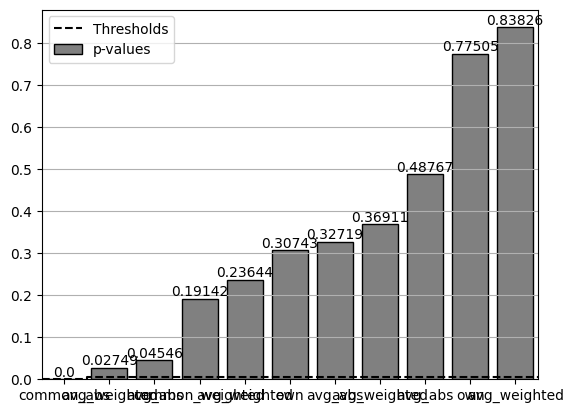

In [90]:

results, figure = bonferroni(rankings, num_cases, alpha, control = None, type_rank = "Friedman")
print(results)
figure.show()


# F1 score statistical test


In [91]:

f1_results2 = f1_results.round(decimals=3).reset_index()
alpha = 0.05
path = os.path.abspath('') + '\\exp2results\\w_niid_dirichlet_quantityf1'
f1_results2.to_csv(path_or_buf=path)
rankings, statistic, p_value, critical_value, hypothesis = friedman(f1_results2, alpha, minimize=False)
print("F1-score results:\n")
print(hypothesis)
print(f"Statistic {statistic}, p-value {p_value}")
print(rankings)


F1-score results:

Fail to Reject H0 with alpha = 0.05 (Same distributions)
Statistic 3.626666666666665, p-value 0.4588814810927091
{'common_abs': 3.4166666666666665, 'common_weighted': 2.8333333333333335, 'own': 2.9166666666666665, 'avg_abs': 3.1166666666666667, 'avg_weighted': 2.716666666666667}


[3.4166666666666665, 2.8333333333333335, 2.9166666666666665, 3.1166666666666667, 2.716666666666667]
1.1136093649857977


C:\Users\mario\AppData\Local\Temp\ipykernel_26668\2903514658.py:5: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  figure.show()


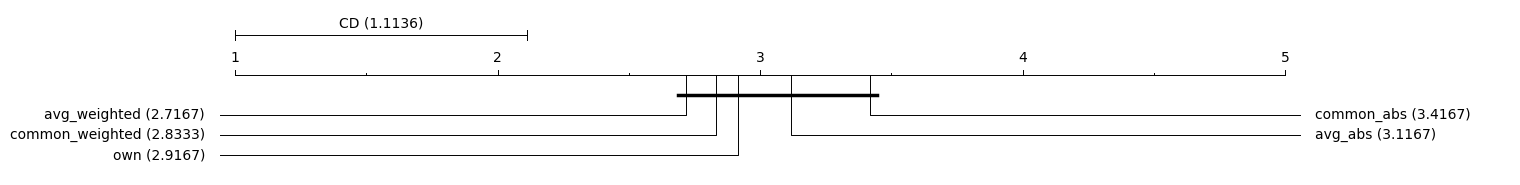

In [92]:

num_cases = f1_results2.shape[0]
ranks_values, critical_distance_nemenyi, figure = nemenyi(rankings, num_cases, alpha)
print(ranks_values)
print(critical_distance_nemenyi)
figure.show()


                        Comparison  Statistic (Z)   p-value  Adjusted alpha  \
0    common_abs vs common_weighted       1.428869  0.153042           0.005   
1                common_abs vs own       1.224745  0.220671           0.005   
2            common_abs vs avg_abs       0.734847  0.462433           0.005   
3       common_abs vs avg_weighted       1.714643  0.086411           0.005   
4           common_weighted vs own       0.204124  0.838256           0.005   
5       common_weighted vs avg_abs       0.694022  0.487668           0.005   
6  common_weighted vs avg_weighted       0.285774  0.775051           0.005   
7                   own vs avg_abs       0.489898  0.624206           0.005   
8              own vs avg_weighted       0.489898  0.624206           0.005   
9          avg_abs vs avg_weighted       0.979796  0.327187           0.005   

   Adjusted p-value  alpha            Results  
0          1.000000   0.05  Fail to Reject H0  
1          1.000000   0.05  Fail t

C:\Users\mario\AppData\Local\Temp\ipykernel_26668\2445730000.py:3: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  figure.show()


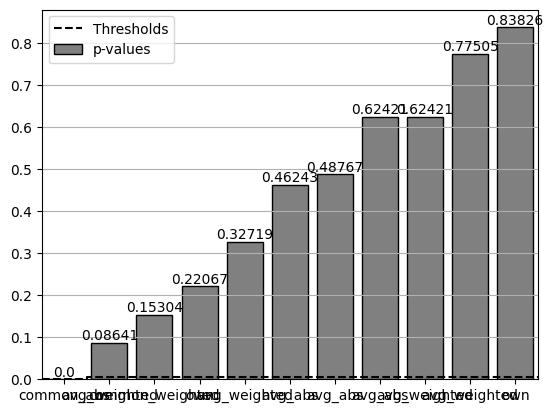

In [93]:

results, figure = bonferroni(rankings, num_cases, alpha, control = None, type_rank = "Friedman")
print(results)
figure.show()

# Non IID label quantity skew (m_v)

In [94]:
dataset = {'nursery':(X_data_nursery,targets_nursery)} #Only nursery bc it is the only one with more than 2 labels
time0 = time.time()
nidd_label_quantity_res = experiment2search(data_distribution='niid_label_quantity_skew',datasets=dataset,distribution_param=3,public_data_prediction='majority_voting')
print("\n[INFO] Total Time (in minutes) =", (time.time() - time0) / 60)
for result in nidd_label_quantity_res:
    print(result)

c:\Users\mario\OneDrive\Escritorio\Programs\gitProjects\TFM_EnsembleFL\.venv\Lib\site-packages\sklearn\model_selection\_split.py:737: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(


c:\Users\mario\OneDrive\Escritorio\Programs\gitProjects\TFM_EnsembleFL\.venv\Lib\site-packages\sklearn\model_selection\_split.py:737: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(
c:\Users\mario\OneDrive\Escritorio\Programs\gitProjects\TFM_EnsembleFL\.venv\Lib\site-packages\sklearn\model_selection\_split.py:737: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
c:\Users\mario\OneDrive\Escritorio\Programs\gitProjects\TFM_EnsembleFL\.venv\Lib\site-packages\sklearn\model_selection\_split.py:737: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
c:\Users\mario\OneDrive\Escritorio\Programs\gitProjects\TFM_EnsembleFL\.venv\Lib\site-packages\sklearn\model_selection\_split.py:737: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
c:\Users\mario\O


[INFO] Total Time (in minutes) = 2.1619293371836346
FLGlobal_acc  common_abs    c_a_std  common_weighted    c_w_std        own  \
nursery        54.728224  21.209229        54.728224  21.209229  54.728224   

FLGlobal_acc    own_std    avg_abs    a_a_std  avg_weighted    a_w_std  
nursery       21.209229  54.728224  21.209229     54.728224  21.209229  
FLlocal_acc  common_abs   c_a_std  common_weighted   c_w_std        own  \
nursery       95.672315  4.351432        95.672315  4.351432  95.672315   

FLlocal_acc   own_std    avg_abs   a_a_std  avg_weighted   a_w_std  
nursery      4.351432  95.672315  4.351432     95.672315  4.351432  
centralized_acc       mean       std
nursery          99.128944  0.350885
FLGlobal_f1  common_abs    c_a_std  common_weighted    c_w_std        own  \
nursery       65.189327  18.831724        65.189327  18.831724  65.189327   

FLGlobal_f1    own_std    avg_abs    a_a_std  avg_weighted    a_w_std  
nursery      18.831724  65.189327  18.831724     65.18

# Accuracy results

In [95]:
_,_,_,_,_,_,acc_results,f1_results = nidd_label_quantity_res
acc_results2 = acc_results.round(decimals=3).reset_index()
path = os.path.abspath('') + '\\exp2results\\niid_dirichlet_quantityacc'
acc_results2.to_csv(path_or_buf=path)
alpha = 0.05
rankings, statistic, p_value, critical_value, hypothesis = friedman(acc_results2, alpha, minimize=False)
print("Accuracy results:\n")
print(hypothesis)
print(f"Statistic {statistic}, p-value {p_value}")
print(rankings)



Accuracy results:

Fail to Reject H0 with alpha = 0.05 (Same distributions)
Statistic 0.0, p-value 1.0
{'common_abs': 3.0, 'common_weighted': 3.0, 'own': 3.0, 'avg_abs': 3.0, 'avg_weighted': 3.0}


[3.0, 3.0, 3.0, 3.0, 3.0]
1.1136093649857977


C:\Users\mario\AppData\Local\Temp\ipykernel_26668\3434521576.py:5: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  figure.show()


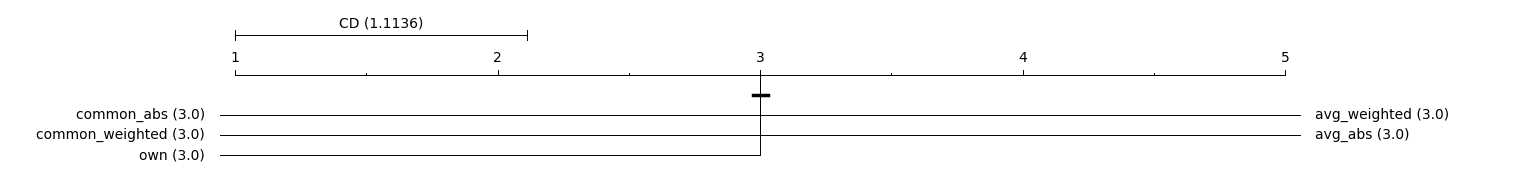

In [96]:

num_cases = acc_results2.shape[0]
ranks_values, critical_distance_nemenyi, figure = nemenyi(rankings, num_cases, alpha)
print(ranks_values)
print(critical_distance_nemenyi)
figure.show()


                        Comparison  Statistic (Z)  p-value  Adjusted alpha  \
0    common_abs vs common_weighted            0.0      1.0           0.005   
1                common_abs vs own            0.0      1.0           0.005   
2            common_abs vs avg_abs            0.0      1.0           0.005   
3       common_abs vs avg_weighted            0.0      1.0           0.005   
4           common_weighted vs own            0.0      1.0           0.005   
5       common_weighted vs avg_abs            0.0      1.0           0.005   
6  common_weighted vs avg_weighted            0.0      1.0           0.005   
7                   own vs avg_abs            0.0      1.0           0.005   
8              own vs avg_weighted            0.0      1.0           0.005   
9          avg_abs vs avg_weighted            0.0      1.0           0.005   

   Adjusted p-value  alpha            Results  
0                 1   0.05  Fail to Reject H0  
1                 1   0.05  Fail to Reject H0

C:\Users\mario\AppData\Local\Temp\ipykernel_26668\844582222.py:3: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  figure.show()


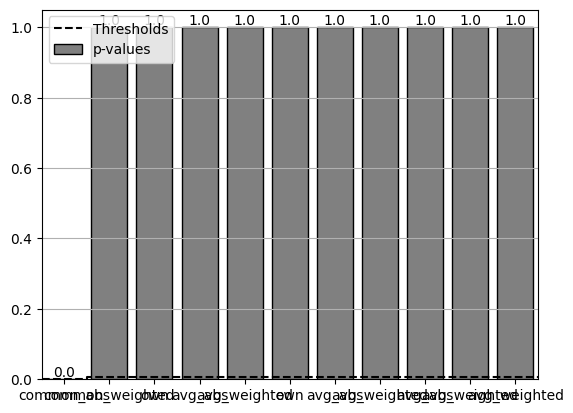

In [97]:

results, figure = bonferroni(rankings, num_cases, alpha, control = None, type_rank = "Friedman")
print(results)
figure.show()


# F1 score statistical test


In [98]:

f1_results2 = f1_results.round(decimals=3).reset_index()
alpha = 0.05
path = os.path.abspath('') + '\\exp2results\\niid_dirichlet_quantityf1'
f1_results2.to_csv(path_or_buf=path)
rankings, statistic, p_value, critical_value, hypothesis = friedman(f1_results2, alpha, minimize=False)
print("F1-score results:\n")
print(hypothesis)
print(f"Statistic {statistic}, p-value {p_value}")
print(rankings)


F1-score results:

Fail to Reject H0 with alpha = 0.05 (Same distributions)
Statistic 0.0, p-value 1.0
{'common_abs': 3.0, 'common_weighted': 3.0, 'own': 3.0, 'avg_abs': 3.0, 'avg_weighted': 3.0}


[3.0, 3.0, 3.0, 3.0, 3.0]
1.1136093649857977


C:\Users\mario\AppData\Local\Temp\ipykernel_26668\2903514658.py:5: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  figure.show()


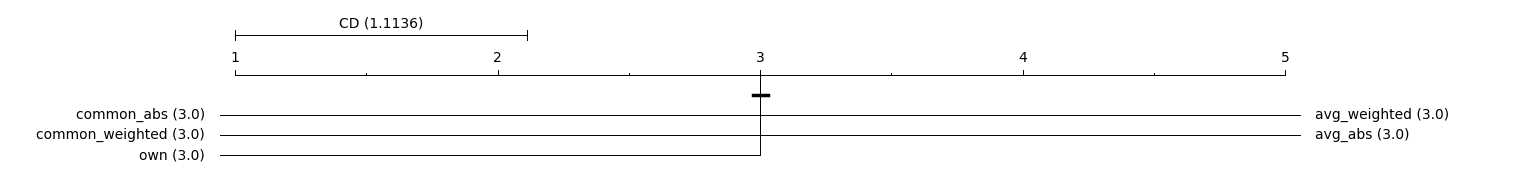

In [99]:

num_cases = f1_results2.shape[0]
ranks_values, critical_distance_nemenyi, figure = nemenyi(rankings, num_cases, alpha)
print(ranks_values)
print(critical_distance_nemenyi)
figure.show()


                        Comparison  Statistic (Z)  p-value  Adjusted alpha  \
0    common_abs vs common_weighted            0.0      1.0           0.005   
1                common_abs vs own            0.0      1.0           0.005   
2            common_abs vs avg_abs            0.0      1.0           0.005   
3       common_abs vs avg_weighted            0.0      1.0           0.005   
4           common_weighted vs own            0.0      1.0           0.005   
5       common_weighted vs avg_abs            0.0      1.0           0.005   
6  common_weighted vs avg_weighted            0.0      1.0           0.005   
7                   own vs avg_abs            0.0      1.0           0.005   
8              own vs avg_weighted            0.0      1.0           0.005   
9          avg_abs vs avg_weighted            0.0      1.0           0.005   

   Adjusted p-value  alpha            Results  
0                 1   0.05  Fail to Reject H0  
1                 1   0.05  Fail to Reject H0

C:\Users\mario\AppData\Local\Temp\ipykernel_26668\2445730000.py:3: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  figure.show()


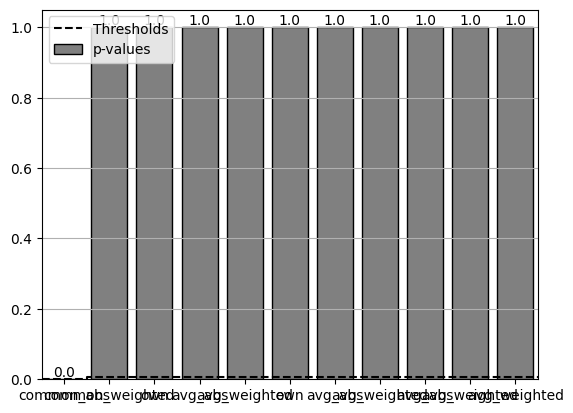

In [100]:

results, figure = bonferroni(rankings, num_cases, alpha, control = None, type_rank = "Friedman")
print(results)
figure.show()

# overall Comparison


In [101]:

# Accuracy
_,_,_,_,_,_,acc_resultsW,f1_resultsW = nidd_label_quantity_resW
acc_resultsW.columns =acc_resultsW.columns + '_W_m_v'
fullacc_results = pd.concat([acc_resultsW,acc_results],axis=1).reset_index()
alpha = 0.05
rankings, statistic, p_value, critical_value, hypothesis = friedman(fullacc_results, alpha, minimize=False)
print("Overall comparison:\n")
print(hypothesis)
print(f"Statistic {statistic}, p-value {p_value}")
print(rankings)



Overall comparison:

Reject H0 with alpha = 0.05 (Different distributions)
Statistic 82.17818181818188, p-value 4.4651282671281933e-11
{'common_abs_W_m_v': 6.216666666666667, 'common_weighted_W_m_v': 7.166666666666667, 'own_W_m_v': 6.55, 'avg_abs_W_m_v': 7.616666666666666, 'avg_weighted_W_m_v': 7.616666666666666, 'common_abs': 3.966666666666667, 'common_weighted': 3.966666666666667, 'own': 3.966666666666667, 'avg_abs': 3.966666666666667, 'avg_weighted': 3.966666666666667}


[6.216666666666667, 7.166666666666667, 6.55, 7.616666666666666, 7.616666666666666, 3.966666666666667, 3.966666666666667, 3.966666666666667, 3.966666666666667, 3.966666666666667]
2.473165095376681


C:\Users\mario\AppData\Local\Temp\ipykernel_26668\2903514658.py:5: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  figure.show()


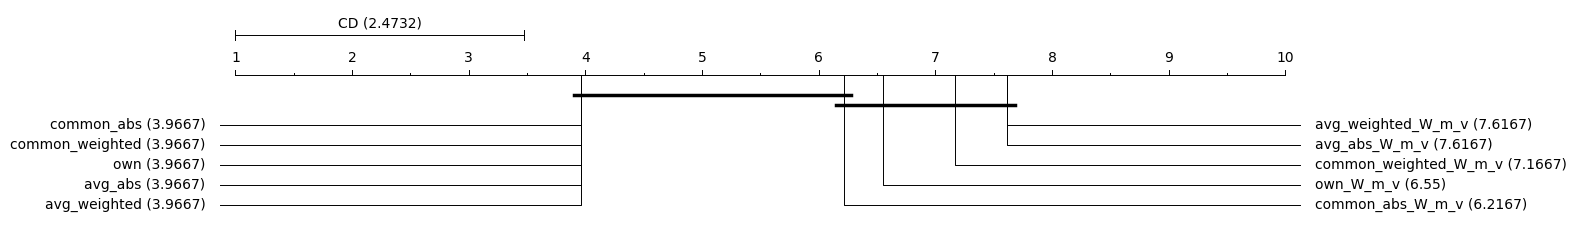

In [102]:

num_cases = f1_results2.shape[0]
ranks_values, critical_distance_nemenyi, figure = nemenyi(rankings, num_cases, alpha)
print(ranks_values)
print(critical_distance_nemenyi)
figure.show()


                                     Comparison  Statistic (Z)   p-value  \
0     common_abs_W_m_v vs common_weighted_W_m_v       1.215244  0.224273   
1                 common_abs_W_m_v vs own_W_m_v       0.426401  0.669815   
2             common_abs_W_m_v vs avg_abs_W_m_v       1.790886  0.073312   
3        common_abs_W_m_v vs avg_weighted_W_m_v       1.790886  0.073312   
4                common_abs_W_m_v vs common_abs       2.878210  0.003999   
5           common_abs_W_m_v vs common_weighted       2.878210  0.003999   
6                       common_abs_W_m_v vs own       2.878210  0.003999   
7                   common_abs_W_m_v vs avg_abs       2.878210  0.003999   
8              common_abs_W_m_v vs avg_weighted       2.878210  0.003999   
9            common_weighted_W_m_v vs own_W_m_v       0.788843  0.430204   
10       common_weighted_W_m_v vs avg_abs_W_m_v       0.575642  0.564857   
11  common_weighted_W_m_v vs avg_weighted_W_m_v       0.575642  0.564857   
12          

C:\Users\mario\AppData\Local\Temp\ipykernel_26668\2222414530.py:3: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  figure.show()


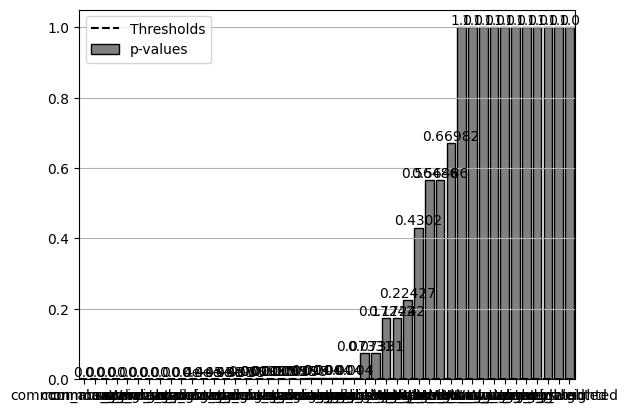

In [103]:


results, figure = bonferroni(rankings, num_cases, alpha, control = None, type_rank = "Friedman")
print(results)
figure.show()


In [104]:

#f1-score
f1_resultsW.columns =f1_resultsW.columns + '_W_m_v'
fullf1_results = pd.concat([f1_resultsW,f1_results],axis=1).reset_index()
rankings, statistic, p_value, critical_value, hypothesis = friedman(fullf1_results, alpha, minimize=False)
print("Overall comparison:\n")
print(hypothesis)
print(f"Statistic {statistic}, p-value {p_value}")
print(rankings)


Overall comparison:

Fail to Reject H0 with alpha = 0.05 (Same distributions)
Statistic 10.418181818181779, p-value 0.3177031258999654
{'common_abs_W_m_v': 5.85, 'common_weighted_W_m_v': 4.916666666666667, 'own_W_m_v': 4.566666666666666, 'avg_abs_W_m_v': 5.116666666666666, 'avg_weighted_W_m_v': 4.716666666666667, 'common_abs': 5.966666666666667, 'common_weighted': 5.966666666666667, 'own': 5.966666666666667, 'avg_abs': 5.966666666666667, 'avg_weighted': 5.966666666666667}


[5.85, 4.916666666666667, 4.566666666666666, 5.116666666666666, 4.716666666666667, 5.966666666666667, 5.966666666666667, 5.966666666666667, 5.966666666666667, 5.966666666666667]
2.473165095376681


C:\Users\mario\AppData\Local\Temp\ipykernel_26668\2903514658.py:5: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  figure.show()


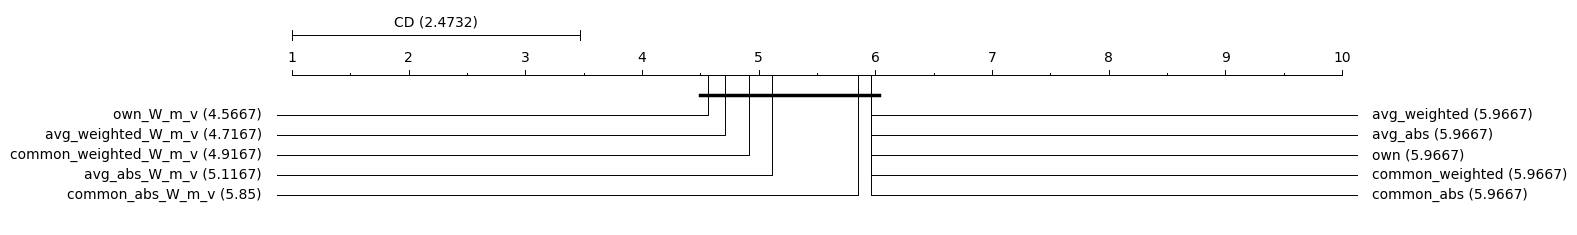

In [105]:

num_cases = f1_results2.shape[0]
ranks_values, critical_distance_nemenyi, figure = nemenyi(rankings, num_cases, alpha)
print(ranks_values)
print(critical_distance_nemenyi)
figure.show()


                                     Comparison  Statistic (Z)   p-value  \
0     common_abs_W_m_v vs common_weighted_W_m_v       1.193924  0.232508   
1                 common_abs_W_m_v vs own_W_m_v       1.641646  0.100663   
2             common_abs_W_m_v vs avg_abs_W_m_v       0.938083  0.348202   
3        common_abs_W_m_v vs avg_weighted_W_m_v       1.449765  0.147124   
4                common_abs_W_m_v vs common_abs       0.149241  0.881364   
5           common_abs_W_m_v vs common_weighted       0.149241  0.881364   
6                       common_abs_W_m_v vs own       0.149241  0.881364   
7                   common_abs_W_m_v vs avg_abs       0.149241  0.881364   
8              common_abs_W_m_v vs avg_weighted       0.149241  0.881364   
9            common_weighted_W_m_v vs own_W_m_v       0.447722  0.654354   
10       common_weighted_W_m_v vs avg_abs_W_m_v       0.255841  0.798074   
11  common_weighted_W_m_v vs avg_weighted_W_m_v       0.255841  0.798074   
12          

C:\Users\mario\AppData\Local\Temp\ipykernel_26668\2445730000.py:3: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  figure.show()


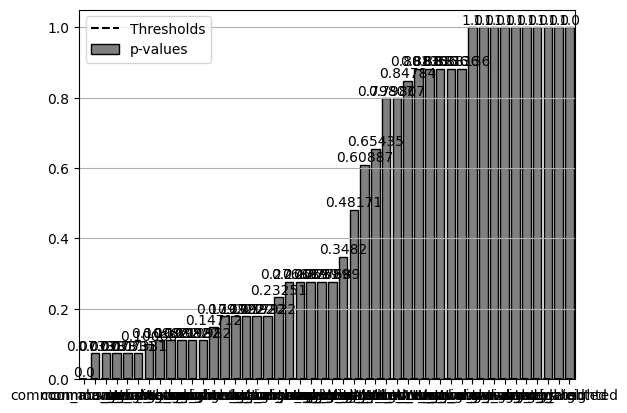

In [106]:

results, figure = bonferroni(rankings, num_cases, alpha, control = None, type_rank = "Friedman")
print(results)
figure.show()

In [107]:
print(np.unique(targets_nursery,return_counts=True))
print(np.unique(targets_adult,return_counts=True))
print(np.unique(targets_bank,return_counts=True)) 

(array([0, 1, 2, 3, 4], dtype=int64), array([4320, 4266,    2, 4044,  328], dtype=int64))
(array([0, 1], dtype=int64), array([24720,  7841], dtype=int64))
(array([0, 1], dtype=int64), array([39922,  5289], dtype=int64))


Análisis de los resultados:

A primera vista es notable que los resultados entre modelos son prácticamente idénticos, lo cual me ha llevado a pensar que podría haber algo mal en el código. 
Sin embargo, hay unas ligeras diferencias en los resultados entre m_v y w_m_v cuando se aplican las distintas distribuciones niid, como ya se observó en el experimento 1. 
Planteo que, mientras que, a pesar de dar unos resultados en media parecidos entre todos los clientes, igual presentan diferencias. Esto es notable estudiando el desempeño de cada cliente por separado. En el caso de uso de pesos comunes para todos (common_abs y common_weighted), mi hipótesis es que aquellos clientes con peor distribución (sea porque tengan pocos datos o esté desbalanceado) tendrán un gran aumento de rendimmiento, mientras que aquellos con mejores distribuciones tendrán una mejora de rendimiento menor. Los otros tres, (own,avg_abs,avg_w), tengo la teoría de que fomentan el buen rendimiento de los clientes con mejores distribuciones, dejando más de lado a aquellos con peores distribuciones. Esto haría que en media se comportaran igual pero que en realidad fuesen distintos. 

Mi hipótesis se basa en los tests que hice anteriormente, por ejemplo el test en breast_cancer/client_and_server/not_balanced/niid/label_dirichlet_skew/experiment2 , se ve que common_abs,common_weighted son más estables a lo largo de los clientes (errorbar). Además, para futuros tests, en solo servidor y usando el balanceo de datos parece que funcionan mejor.

Considero que, ante mismo rendimiento en media, es más conveniente que todos mejoren su rendimiento, pues así tienen un aliciente para participar en el proceso federado. 

Hay que destacar que se conoce que los modelos de HFL creo que suelen ser más inestables ante este tipo de desbalanceo (label_quantity/label_dirichlet), pero todo lo que se pueda mejorar es bienvenido. 